In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

SAVE_PATH = "/content/drive/MyDrive/TimeSeriesModels/"
os.makedirs(SAVE_PATH, exist_ok=True)

print(f"✅ Google Drive mounted and save path created: {SAVE_PATH}")

✅ Google Drive mounted and save path created: /content/drive/MyDrive/TimeSeriesModels/


All subsequent model and scaler saves will now target this Google Drive path.

# 🛒 Rossmann Store Sales Forecasting — Deep Learning Models

> **Aggregate daily sales forecasting** using SimpleRNN, LSTM, BiLSTM, GRU, Transformer, TCN, N-HiTS, PatchTST, and Amazon Chronos.
>
> **Improvements over baseline:** richer lag/rolling features, cyclical DayOfWeek encoding, trend feature, larger window (60), Huber loss, BatchNorm, heavier models, and stricter callbacks.

---

# 🔷 PART 1 — Point Prediction Models

> Models that output a **single value** (next-day sales forecast) optimised with Huber loss.

## 📦 SECTION 0 — Imports & Global Setup

In [ ]:
import pickle
import os

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    SimpleRNN, LSTM, GRU, Dense, Dropout,
    BatchNormalization, Bidirectional,
    Conv1D, MaxPooling1D, Flatten,
    Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D,
    Add, Activation
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from statsmodels.graphics.tsaplots import plot_acf

# ── Reproducibility ──
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Global hyper-params ──
WINDOW_SIZE  = 60      # captures 2 months of history
SPLIT_RATIO  = 0.80
BATCH_SIZE   = 32
MAX_EPOCHS   = 150
PATIENCE_ES  = 20
PATIENCE_LR  = 8

print("✅ All imports successful. TF version:", tf.__version__)
print(f"   Window={WINDOW_SIZE} | Split={SPLIT_RATIO} | Batch={BATCH_SIZE} | MaxEpochs={MAX_EPOCHS}")

✅ All imports successful. TF version: 2.19.0
   Window=60 | Split=0.8 | Batch=32 | MaxEpochs=150


## 📥 SECTION 1 — Load Data

In [ ]:
df_train = pd.read_csv(
    'https://raw.githubusercontent.com/sarthaksoni25/Rossmann-Store-Sales-Prediction/'
    'refs/heads/master/dataset/train.csv',
    low_memory=False
)
print(f"Shape: {df_train.shape}")
display(df_train.head())

Shape: (1001599, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931


## 🧹 SECTION 2 — Filter Data (Remove Closed Days)

In [ ]:
df_train = df_train[df_train['Open'] != 0].drop('Open', axis=1)
print(f"Shape after removing closed days: {df_train.shape}")
display(df_train.head())

Shape after removing closed days: (830972, 9)


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,0,1,981931


## 📅 SECTION 3 — Date Feature Engineering

> **Improvements:** Added cyclical `DayOfWeek` encoding (sin/cos) and a monotone `Trend` feature.

In [ ]:
df_train['Date'] = pd.to_datetime(df_train['Date'])

df_train['Year']       = df_train['Date'].dt.year
df_train['Month']      = df_train['Date'].dt.month
df_train['Day']        = df_train['Date'].dt.day
df_train['WeekOfYear'] = df_train['Date'].dt.isocalendar().week.astype(int)
df_train['IsWeekend']  = ((df_train['DayOfWeek'] == 6) | (df_train['DayOfWeek'] == 7)).astype(int)

# Cyclical encoding — Month
df_train['Month_sin'] = np.sin(2 * np.pi * df_train['Month'] / 12)
df_train['Month_cos'] = np.cos(2 * np.pi * df_train['Month'] / 12)

# Cyclical encoding — DayOfWeek
df_train['DayOfWeek_sin'] = np.sin(2 * np.pi * df_train['DayOfWeek'] / 7)
df_train['DayOfWeek_cos'] = np.cos(2 * np.pi * df_train['DayOfWeek'] / 7)

df_train = df_train.set_index('Date').sort_index()
print(f"Shape: {df_train.shape}")
display(df_train.head())

Shape: (830972, 17)


,Store,DayOfWeek,Sales,Customers,Promo,StateHoliday,SchoolHoliday,Id,Year,Month,Day,WeekOfYear,IsWeekend,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
Date,,,,,,,,,,,,,,,,,
2013-01-01,1097,2,5961,1405,0,a,1,929828,2013,1,1,1,0,0.5,0.866025,0.974928,-0.222521
2013-01-01,85,2,4220,619,0,a,1,251058,2013,1,1,1,0,0.5,0.866025,0.974928,-0.222521
2013-01-01,259,2,6851,1444,0,a,1,277230,2013,1,1,1,0,0.5,0.866025,0.974928,-0.222521
2013-01-01,262,2,17267,2875,0,a,1,133823,2013,1,1,1,0,0.5,0.866025,0.974928,-0.222521
2013-01-01,274,2,3102,729,0,a,1,575985,2013,1,1,1,0,0.5,0.866025,0.974928,-0.222521


## 📊 SECTION 4 — Aggregate to Daily Level

In [ ]:
aggregated_df = df_train.groupby('Date').agg(
    Sales        = ('Sales',        'sum'),
    SchoolHoliday= ('SchoolHoliday','mean'),
    Promo        = ('Promo',        'mean'),
    Year         = ('Year',         'first'),
    Month        = ('Month',        'first'),
    Day          = ('Day',          'first'),
    WeekOfYear   = ('WeekOfYear',   'first'),
    DayOfWeek    = ('DayOfWeek',    'first'),
    IsWeekend    = ('IsWeekend',    'first'),
    Month_sin    = ('Month_sin',    'first'),
    Month_cos    = ('Month_cos',    'first'),
    DayOfWeek_sin= ('DayOfWeek_sin','first'),
    DayOfWeek_cos= ('DayOfWeek_cos','first'),
).reset_index().set_index('Date').sort_index()

print(f"Aggregated shape: {aggregated_df.shape}")
display(aggregated_df.head())

Aggregated shape: (928, 13)


,Sales,SchoolHoliday,Promo,Year,Month,Day,WeekOfYear,DayOfWeek,IsWeekend,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
Date,,,,,,,,,,,,,
2013-01-01,97235,1.000000,0.0,2013,1,1,1,2,0,0.5,0.866025,0.974928,-0.222521
2013-01-02,6949829,1.000000,0.0,2013,1,2,1,3,0,0.5,0.866025,0.433884,-0.900969
2013-01-03,6347820,0.932372,0.0,2013,1,3,1,4,0,0.5,0.866025,-0.433884,-0.900969
2013-01-04,6638954,0.932310,0.0,2013,1,4,1,5,0,0.5,0.866025,-0.974928,-0.222521
2013-01-05,5951593,0.100271,0.0,2013,1,5,1,6,1,0.5,0.866025,-0.781831,0.623490


In [ ]:
aggregated_df.loc['2013-05-15']

,2013-05-15
Sales,7.767784e+06
SchoolHoliday,5.035971e-02
Promo,1.000000e+00
Year,2.013000e+03
Month,5.000000e+00
Day,1.500000e+01
WeekOfYear,2.000000e+01
DayOfWeek,3.000000e+00
IsWeekend,0.000000e+00
Month_sin,5.000000e-01


## 📈 SECTION 5 — ACF Plot

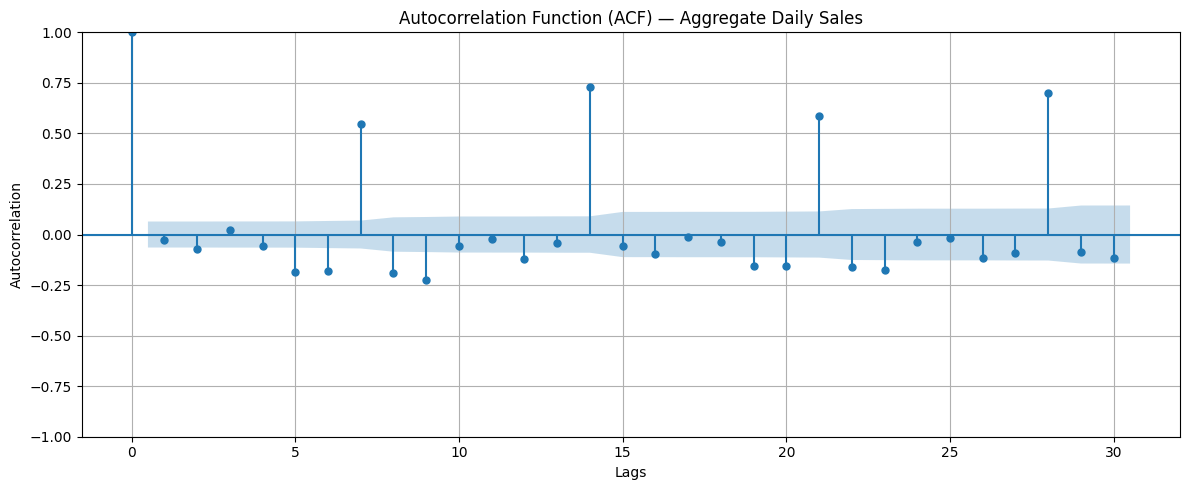

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(aggregated_df['Sales'], lags=30, ax=ax)
ax.set_title('Autocorrelation Function (ACF) — Aggregate Daily Sales')
ax.set_xlabel('Lags'); ax.set_ylabel('Autocorrelation')
ax.grid(True)
plt.tight_layout()
plt.show()

## 🔥 SECTION 6 — Enhanced Lag & Rolling Features

> **Improvements:** Extra lags (21, 28) + rolling_mean_14/30 + rolling_std_7 (volatility) + Trend.
> All computed with `.shift(1)` to avoid data leakage.

In [ ]:
s = aggregated_df['Sales']

# Lag features
aggregated_df['Sales_lag_1']  = s.shift(1)
aggregated_df['Sales_lag_7']  = s.shift(7)
aggregated_df['Sales_lag_14'] = s.shift(14)
aggregated_df['Sales_lag_21'] = s.shift(21)
aggregated_df['Sales_lag_28'] = s.shift(28)

# Rolling statistics (all shifted by 1 to prevent leakage)
aggregated_df['Rolling_mean_7']  = s.shift(1).rolling(7).mean()
aggregated_df['Rolling_mean_14'] = s.shift(1).rolling(14).mean()
aggregated_df['Rolling_mean_30'] = s.shift(1).rolling(30).mean()
aggregated_df['Rolling_std_7']   = s.shift(1).rolling(7).std()

# Trend (days since first date — monotone linear signal)
aggregated_df['Trend'] = np.arange(len(aggregated_df))

display(aggregated_df.head(35))
print(f"Shape with new features: {aggregated_df.shape}")

,Sales,SchoolHoliday,Promo,Year,Month,Day,WeekOfYear,DayOfWeek,IsWeekend,Month_sin,...,Sales_lag_1,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,Rolling_mean_7,Rolling_mean_14,Rolling_mean_30,Rolling_std_7,Trend
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,97235,1.000000,0.0,2013,1,1,1,2,0,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2013-01-02,6949829,1.000000,0.0,2013,1,2,1,3,0,0.500000,...,97235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2013-01-03,6347820,0.932372,0.0,2013,1,3,1,4,0,0.500000,...,6949829.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2013-01-04,6638954,0.932310,0.0,2013,1,4,1,5,0,0.500000,...,6347820.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
2013-01-05,5951593,0.100271,0.0,2013,1,5,1,6,1,0.500000,...,6638954.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
2013-01-06,143904,0.157895,0.0,2013,1,6,1,7,1,0.500000,...,5951593.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
2013-01-07,10826848,0.100362,1.0,2013,1,7,2,1,0,0.500000,...,143904.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
2013-01-08,8749437,0.100452,1.0,2013,1,8,2,2,0,0.500000,...,10826848.0,97235.0,NaN,NaN,NaN,5.279455e+06,NaN,NaN,3.878024e+06,7
2013-01-09,7746603,0.100452,1.0,2013,1,9,2,3,0,0.500000,...,8749437.0,6949829.0,NaN,NaN,NaN,6.515484e+06,NaN,NaN,3.284444e+06,8


Shape with new features: (928, 23)


## ⚠️ SECTION 7 — Handle Null Values

In [ ]:
aggregated_df_cleaned = aggregated_df.dropna()
print(f"Shape after dropna: {aggregated_df_cleaned.shape}")
print()
print('Feature ranges (raw):')
print(aggregated_df_cleaned.drop('Sales', axis=1).describe().T[['min', 'max']])

Shape after dropna: (898, 23)

Feature ranges (raw):
                          min           max
SchoolHoliday    0.000000e+00  1.000000e+00
Promo            0.000000e+00  1.000000e+00
Year             2.013000e+03  2.015000e+03
Month            1.000000e+00  1.200000e+01
Day              1.000000e+00  3.100000e+01
WeekOfYear       1.000000e+00  5.200000e+01
DayOfWeek        1.000000e+00  7.000000e+00
IsWeekend        0.000000e+00  1.000000e+00
Month_sin       -1.000000e+00  1.000000e+00
Month_cos       -1.000000e+00  1.000000e+00
DayOfWeek_sin   -9.749279e-01  9.749279e-01
DayOfWeek_cos   -9.009689e-01  1.000000e+00
Sales_lag_1      1.181080e+05  1.562355e+07
Sales_lag_7      1.181080e+05  1.562355e+07
Sales_lag_14     1.181080e+05  1.562355e+07
Sales_lag_21     1.181080e+05  1.562355e+07
Sales_lag_28     1.181080e+05  1.562355e+07
Rolling_mean_7   3.588075e+06  1.076733e+07
Rolling_mean_14  4.420632e+06  9.159216e+06
Rolling_mean_30  4.962116e+06  8.227152e+06
Rolling_std_7    1.8248

## 🎯 SECTION 8 — Create Target Variable (Next-Day Sales)

In [ ]:
df = aggregated_df_cleaned.copy()

df['Target'] = df['Sales'].shift(-1)
df = df.dropna().reset_index(drop=True)

print(f"Final DataFrame shape: {df.shape}")
display(df.head())

Final DataFrame shape: (897, 24)


,Sales,SchoolHoliday,Promo,Year,Month,Day,WeekOfYear,DayOfWeek,IsWeekend,Month_sin,...,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,Rolling_mean_7,Rolling_mean_14,Rolling_mean_30,Rolling_std_7,Trend,Target
0,7068567,0.019856,0.0,2013,1,31,5,4,0,0.500000,...,7439836.0,5386564.0,7751485.0,6347820.0,5.493342e+06,5.783335e+06,5.768788e+06,2.519886e+06,30,7203007.0
1,7203007,0.095582,0.0,2013,2,1,5,5,0,0.866025,...,7780789.0,6137010.0,8039306.0,6638954.0,5.440303e+06,5.903478e+06,6.001166e+06,2.475606e+06,31,6781741.0
2,6781741,0.000000,0.0,2013,2,2,5,6,1,0.866025,...,5848770.0,6010192.0,6017491.0,5951593.0,5.357763e+06,5.979620e+06,6.009605e+06,2.392812e+06,32,171565.0
3,171565,0.000000,0.0,2013,2,3,5,7,1,0.866025,...,142848.0,151600.0,144052.0,143904.0,5.491045e+06,6.034731e+06,6.024069e+06,2.450020e+06,33,10333651.0
4,10333651,0.197475,1.0,2013,2,4,6,1,0,0.866025,...,5878702.0,8761074.0,5886788.0,10826848.0,5.495147e+06,6.036157e+06,5.808489e+06,2.439574e+06,34,8841604.0


## ⚙️ SECTION 9 — Feature Selection & Min-Max Scaling

In [ ]:
features_raw = df.drop(['Sales', 'Target'], axis=1)
target_raw   = df['Target'].values

print(f"Features: {features_raw.shape}  |  Target: {target_raw.shape}")
print(f"Feature columns ({len(features_raw.columns)}): {list(features_raw.columns)}")

feature_scaler = MinMaxScaler(feature_range=(0, 1))
features_scaled = feature_scaler.fit_transform(features_raw)

target_scaler  = MinMaxScaler(feature_range=(0, 1))
target_scaled  = target_scaler.fit_transform(target_raw.reshape(-1, 1)).flatten()

# ── Future known features (t+1 conditioning) ──────────────────────────────
USE_FUTURE_FEATURES = True
FUTURE_FEATURE_COLS = ['DayOfWeek', 'Promo', 'SchoolHoliday']
N_FUTURE_FEATS      = len(FUTURE_FEATURE_COLS)

future_scaler          = MinMaxScaler(feature_range=(0, 1))
future_features_raw    = df[FUTURE_FEATURE_COLS].values
future_features_scaled = future_scaler.fit_transform(future_features_raw)

print(f"\nTarget scaled — min: {target_scaled.min():.4f}, max: {target_scaled.max():.4f} ✅")
print("All features in [0, 1] ✅")
print(f"Future features shape: {future_features_scaled.shape}  cols: {FUTURE_FEATURE_COLS} ✅")


Features: (897, 22)  |  Target: (897,)
Feature columns (22): ['SchoolHoliday', 'Promo', 'Year', 'Month', 'Day', 'WeekOfYear', 'DayOfWeek', 'IsWeekend', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14', 'Sales_lag_21', 'Sales_lag_28', 'Rolling_mean_7', 'Rolling_mean_14', 'Rolling_mean_30', 'Rolling_std_7', 'Trend']

Target scaled — min: 0.0000, max: 1.0000 ✅
All features in [0, 1] ✅
Future features shape: (897, 3)  cols: ['DayOfWeek', 'Promo', 'SchoolHoliday'] ✅


## 🔢 SECTION 10 — Create Sliding-Window Sequences

> `WINDOW_SIZE = 60` so each sample covers two months of history.

In [ ]:
X_seq, X_future, y = [], [], []
for i in range(WINDOW_SIZE, len(features_scaled)):
    X_seq.append(features_scaled[i - WINDOW_SIZE : i])   # past window  t-60 → t-1
    X_future.append(future_features_scaled[i])            # known feats  at t
    y.append(target_scaled[i])                            # target       at t

X_seq    = np.array(X_seq)
X_future = np.array(X_future)
y        = np.array(y)

print(f"X_seq shape    (samples, window, features): {X_seq.shape}")
print(f"X_future shape (samples, n_future_feats):   {X_future.shape}")
print(f"y shape        (samples,):                  {y.shape}")


X_seq shape    (samples, window, features): (837, 60, 22)
X_future shape (samples, n_future_feats):   (837, 3)
y shape        (samples,):                  (837,)


## ✂️ SECTION 11 — Chronological Train / Test Split

In [ ]:
split_index = int(len(X_seq) * SPLIT_RATIO)

X_seq_train,    X_seq_test    = X_seq[:split_index],    X_seq[split_index:]
X_future_train, X_future_test = X_future[:split_index], X_future[split_index:]
y_train,        y_test        = y[:split_index],         y[split_index:]

# Backward-compat aliases (used by Chronos unchanged)
X_train = X_seq_train
X_test  = X_seq_test

# Unscaled actuals for evaluation
y_test_raw = target_raw[WINDOW_SIZE:][split_index:]

print(f"Train: X_seq={X_seq_train.shape}  X_future={X_future_train.shape}  y={y_train.shape}")
print(f"Test : X_seq={X_seq_test.shape}   X_future={X_future_test.shape}   y={y_test.shape}")
print(f"y_test_raw shape: {y_test_raw.shape}")


Train: X_seq=(669, 60, 22)  X_future=(669, 3)  y=(669,)
Test : X_seq=(168, 60, 22)   X_future=(168, 3)   y=(168,)
y_test_raw shape: (168,)


## 🔧 Helper: Shared Callbacks & Evaluation Utilities

In [ ]:
def make_callbacks(name):
    """Return EarlyStopping + ReduceLROnPlateau callbacks for any model."""
    return [
        EarlyStopping(monitor='val_loss', patience=PATIENCE_ES,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=PATIENCE_LR,
                          min_lr=1e-6, verbose=1)
    ]

def evaluate_model(name, y_true, y_pred_scaled, scaler):
    """Inverse-transform predictions and print RMSE / MAE / MAPE / R2."""
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    # Handle MAPE instability: add small epsilon to y_true if near zero
    mape = mean_absolute_percentage_error(y_true + 1e-8, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:20s}  RMSE: {rmse:>12,.2f}  |  MAE: {mae:>12,.2f}  |  MAPE: {mape:>12.2%}  |  R2: {r2:>12.2f}")
    return y_pred, rmse, mae, mape, r2

def plot_history(history, model_name):
    """Plot train/val loss and MAE curves."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{model_name} — Loss'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history.history['mae'],      label='Train MAE')
    axes[1].plot(history.history['val_mae'],  label='Val MAE')
    axes[1].set_title(f'{model_name} — MAE');  axes[1].legend(); axes[1].grid(True)
    plt.suptitle(f'{model_name} Training History', fontsize=12)
    plt.tight_layout(); plt.show()

def plot_predictions(y_true, y_pred, model_name, color, rmse, mae, points=200):
    """Plot actual vs predicted for first `points` test samples."""
    n = min(points, len(y_true))
    plt.figure(figsize=(15, 5))
    plt.plot(y_true[:n],  label='Actual Sales',       color='steelblue', lw=2)
    plt.plot(y_pred[:n],  label=f'{model_name} Pred', color=color,       lw=1.5, ls='--')
    plt.title(f'{model_name} — Actual vs Predicted\nRMSE: {rmse:,.0f}  |  MAE: {mae:,.0f}', fontsize=12)
    plt.xlabel('Time Step'); plt.ylabel('Aggregate Sales')
    plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

results = {}   # {model_name: (y_pred_array, rmse, mae)}
print("✅ Helper functions defined.")

✅ Helper functions defined.


---
## 🟨 MODEL 0 — Feedforward Neural Network (FNN) *(Baseline)*

> Non-sequential baseline showing the importance of temporal awareness.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

# Flatten sequence and append known future features
X_train_flat = np.concatenate(
    [X_seq_train.reshape(X_seq_train.shape[0], -1), X_future_train], axis=1)
X_test_flat  = np.concatenate(
    [X_seq_test.reshape(X_seq_test.shape[0], -1),  X_future_test],  axis=1)

print(f"Flattened+future X_train shape: {X_train_flat.shape}")
print(f"Flattened+future X_test shape:  {X_test_flat.shape}")

model_fnn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_flat.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='FNN_Model')
model_fnn.summary()


Flattened+future X_train shape: (669, 1323)
Flattened+future X_test shape:  (168, 1323)


Model: "FNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_71 (Dense)                │ (None, 128)            │       169,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,841 (702.50 KB)

 Trainable params: 179,841 (702.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 303ms/step - loss: 0.0159 - mae: 0.1340 - val_loss: 0.0122 - val_mae: 0.1245 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0090 - mae: 0.0982 - val_loss: 0.0091 - val_mae: 0.0998 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0075 - mae: 0.0837 - val_loss: 0.0082 - val_mae: 0.0862 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0064 - mae: 0.0783 - val_loss: 0.0102 - val_mae: 0.1053 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0068 - mae: 0.0787 - val_loss: 0.0077 - val_mae: 0.0855 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0061 - mae: 0.0729 - val_loss: 0.0094 - val_mae: 0.0996 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0059 - mae: 0.0715 - val_loss: 0.0075 - val_mae: 0.0854 - learning_rate: 0.0010
Epoch

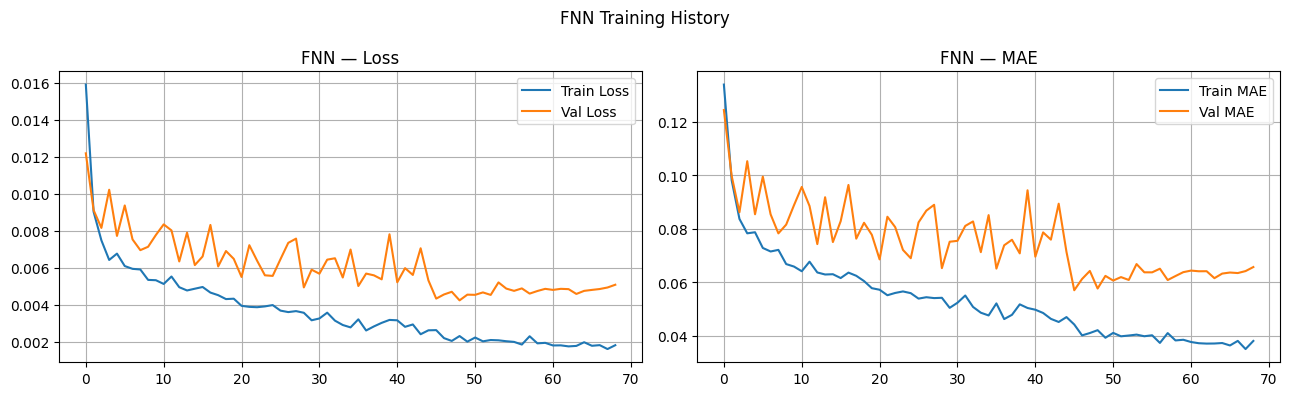

In [ ]:
model_fnn.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])

history_fnn = model_fnn.fit(
    X_train_flat, y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_test_flat, y_test),
    callbacks=make_callbacks('FNN'), verbose=1
)
plot_history(history_fnn, 'FNN')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
FNN                   RMSE: 1,427,675.12  |  MAE:   894,281.62  |  MAPE:       69.60%  |  R2:         0.81


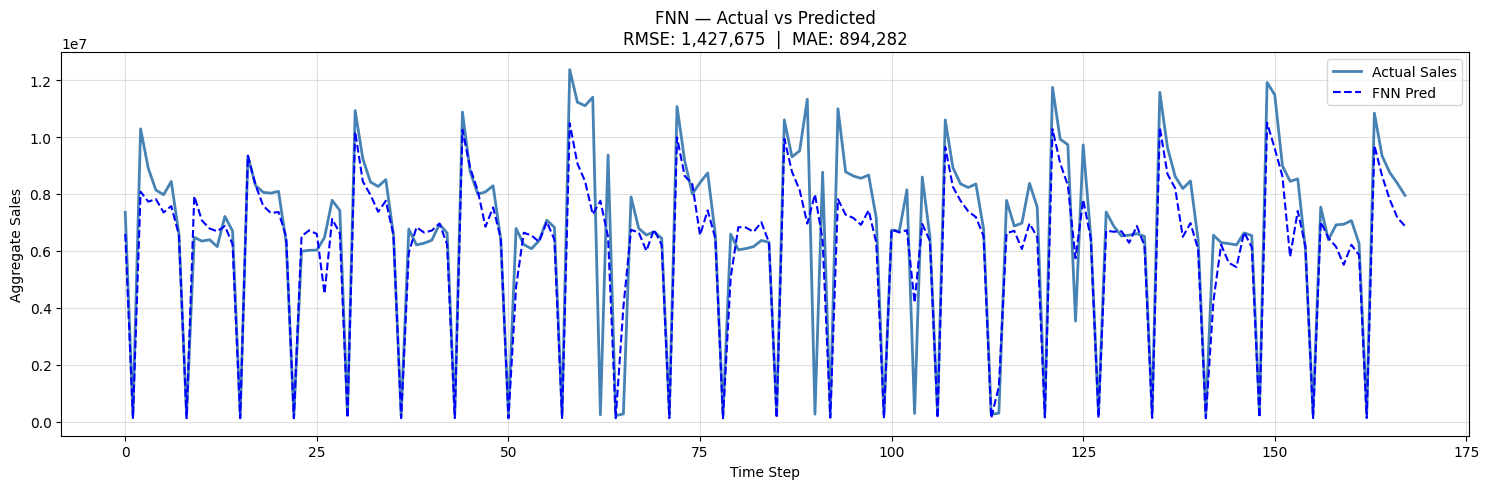

In [ ]:
y_pred_fnn_scaled = model_fnn.predict(X_test_flat)
y_pred_fnn, rmse_fnn, mae_fnn, mape_fnn, r2_fnn = evaluate_model('FNN', y_test_raw, y_pred_fnn_scaled, target_scaler)
results['FNN'] = {"y_pred": y_pred_fnn, "RMSE": rmse_fnn, "MAE": mae_fnn, "MAPE": mape_fnn, "R2": r2_fnn}
plot_predictions(y_test_raw, y_pred_fnn, 'FNN', 'blue', rmse_fnn, mae_fnn)

In [ ]:
# Save FNN point model
model_fnn.save(SAVE_PATH + "fnn_model.h5")
model_fnn.save(SAVE_PATH + "fnn_model.keras")
with open(SAVE_PATH + "fnn_model.pkl", "wb") as f:
    pickle.dump(model_fnn, f)

---
## 🔵 MODEL 1 — SimpleRNN

> Huber loss (robust to sales outliers), BatchNorm, sigmoid output.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

seq_input = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='seq_input')
x = SimpleRNN(128, return_sequences=True)(seq_input)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = SimpleRNN(64, return_sequences=False)(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)

future_input = Input(shape=(N_FUTURE_FEATS,), name='future_input')
combined = layers.Concatenate()([x, future_input])
out = Dense(1, activation='sigmoid')(combined)

model_rnn = Model(inputs=[seq_input, future_input], outputs=out, name='SimpleRNN_Model')
model_rnn.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_4        │ (None, 60, 128)   │     19,328 │ seq_input[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ simple_rnn_4[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_59          │ (None, 60, 128)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_5        │ (None, 64)        │     12,352 │ dropout_59[0][0]  │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ simple_rnn_5[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_60          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_75 (Dense)    │ (None, 32)        │      2,080 │ dropout_60[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 35)        │          0 │ dense_75[0][0],   │
│ (Concatenate)       │                   │            │ future_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_76 (Dense)    │ (None, 1)         │         36 │ concatenate_11[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,564 (135.02 KB)

 Trainable params: 34,180 (133.52 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 254ms/step - loss: 0.0195 - mae: 0.1539 - val_loss: 0.0109 - val_mae: 0.1083 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0112 - mae: 0.1132 - val_loss: 0.0098 - val_mae: 0.0972 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0092 - mae: 0.1034 - val_loss: 0.0094 - val_mae: 0.0988 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0081 - mae: 0.0944 - val_loss: 0.0080 - val_mae: 0.0892 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0068 - mae: 0.0857 - val_loss: 0.0078 - val_mae: 0.0873 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0067 - mae: 0.0827 - val_loss: 0.0075 - val_mae: 0.0789 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0068 - mae: 0.0845 - val_loss: 0.0072 - val_mae: 0.0789 - learning_rate: 0.0010
Epoc

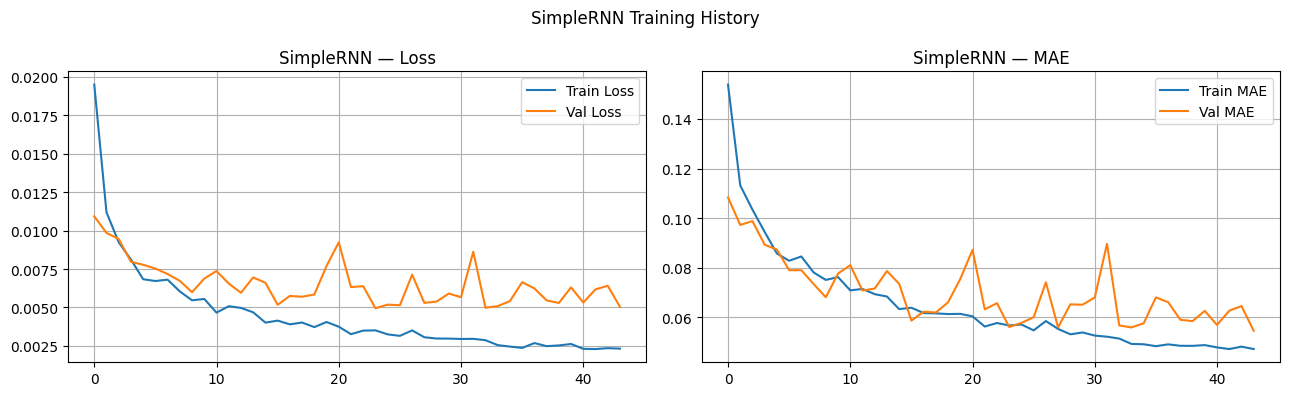

In [ ]:
model_rnn.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])

history_rnn = model_rnn.fit(
    [X_seq_train, X_future_train], y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_future_test], y_test),
    callbacks=make_callbacks('RNN'), verbose=1
)
plot_history(history_rnn, 'SimpleRNN')


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step
SimpleRNN             RMSE: 1,543,141.64  |  MAE:   868,216.34  |  MAPE:       86.89%  |  R2:         0.78


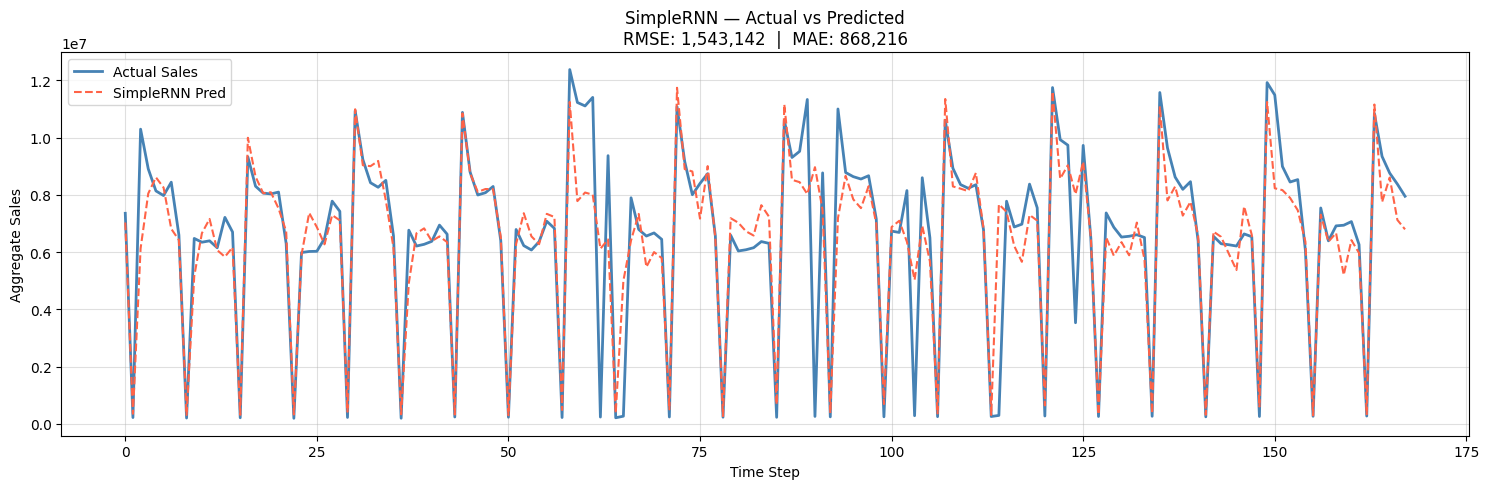

In [ ]:
y_pred_rnn_scaled = model_rnn.predict([X_seq_test, X_future_test])
y_pred_rnn, rmse_rnn, mae_rnn, mape_rnn, r2_rnn = evaluate_model('SimpleRNN', y_test_raw, y_pred_rnn_scaled, target_scaler)
results['SimpleRNN'] = {"y_pred": y_pred_rnn, "RMSE": rmse_rnn, "MAE": mae_rnn, "MAPE": mape_rnn, "R2": r2_rnn}
plot_predictions(y_test_raw, y_pred_rnn, 'SimpleRNN', 'tomato', rmse_rnn, mae_rnn)


---
## 🟢 MODEL 2 — LSTM

> 128→64 units, BatchNorm, Huber loss, L2 regularization.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

seq_input = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='seq_input')
x = LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4))(seq_input)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = LSTM(64, return_sequences=False, kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)

future_input = Input(shape=(N_FUTURE_FEATS,), name='future_input')
combined = layers.Concatenate()([x, future_input])
out = Dense(1, activation='sigmoid')(combined)

model_lstm = Model(inputs=[seq_input, future_input], outputs=out, name='LSTM_Model')
model_lstm.summary()


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 60, 128)   │     77,312 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ lstm_4[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_61          │ (None, 60, 128)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 64)        │     49,408 │ dropout_61[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ lstm_5[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_62          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_77 (Dense)    │ (None, 32)        │      2,080 │ dropout_62[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 35)        │          0 │ dense_77[0][0],   │
│ (Concatenate)       │                   │            │ future_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_78 (Dense)    │ (None, 1)         │         36 │ concatenate_12[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 129,604 (506.27 KB)

 Trainable params: 129,220 (504.77 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0619 - mae: 0.2216 - val_loss: 0.0477 - val_mae: 0.1713 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0463 - mae: 0.1774 - val_loss: 0.0468 - val_mae: 0.1724 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0418 - mae: 0.1652 - val_loss: 0.0457 - val_mae: 0.1665 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0387 - mae: 0.1522 - val_loss: 0.0446 - val_mae: 0.1637 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0368 - mae: 0.1490 - val_loss: 0.0438 - val_mae: 0.1633 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0347 - mae: 0.1403 - val_loss: 0.0428 - val_mae: 0.1634 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0339 - mae: 0.1405 - val_loss: 0.0417 - val_mae: 0.1561 - learning_rate: 0.0010
Epoch 

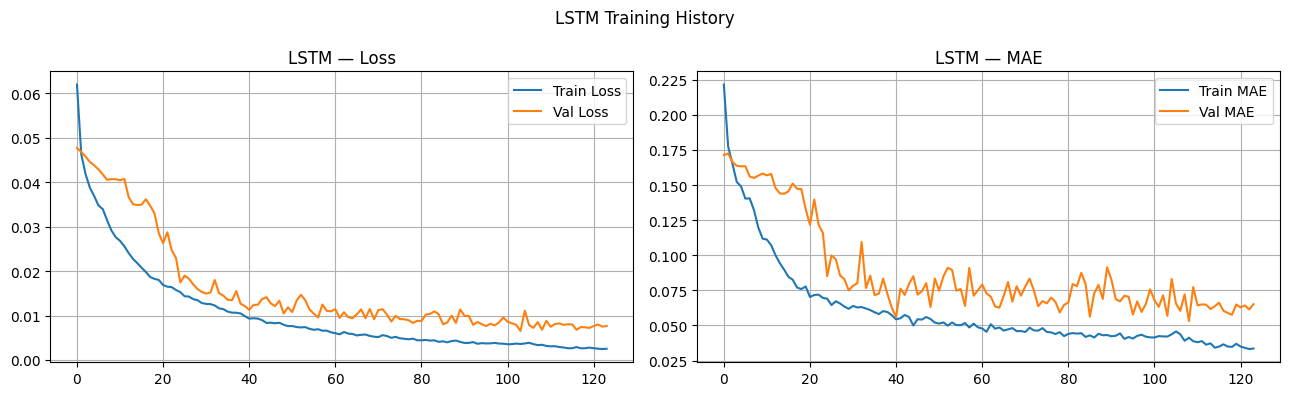

In [ ]:
model_lstm.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])

history_lstm = model_lstm.fit(
    [X_seq_train, X_future_train], y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_future_test], y_test),
    callbacks=make_callbacks('LSTM'), verbose=1
)
plot_history(history_lstm, 'LSTM')


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
LSTM                  RMSE: 1,537,578.37  |  MAE:   881,887.43  |  MAPE:       83.42%  |  R2:         0.78


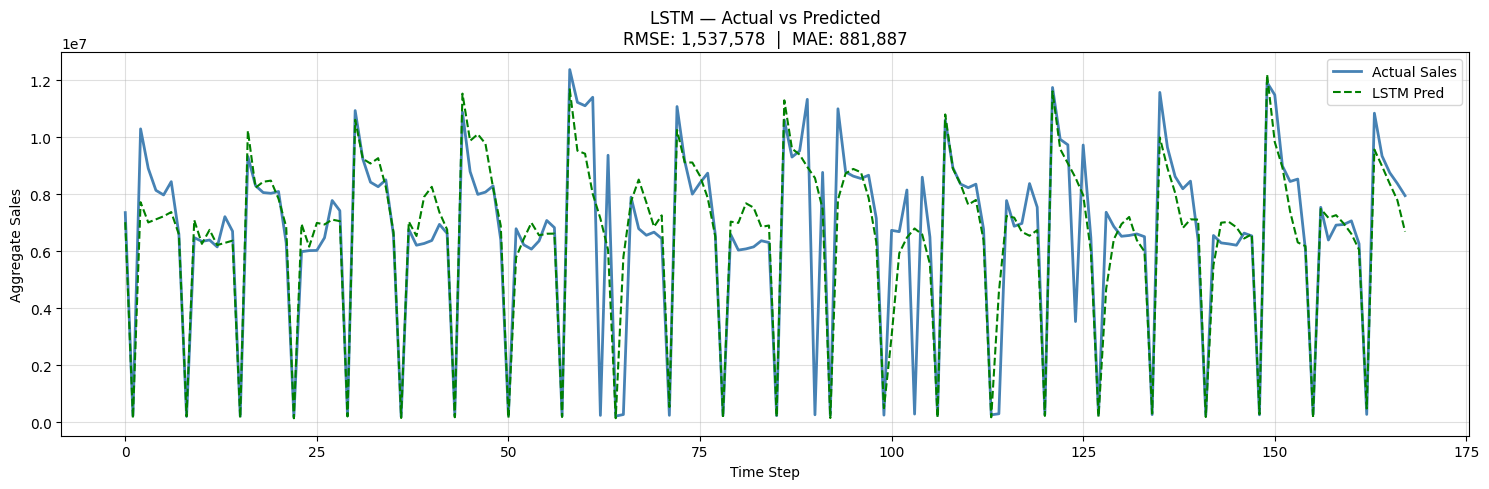

In [ ]:
y_pred_lstm_scaled = model_lstm.predict([X_seq_test, X_future_test])
y_pred_lstm, rmse_lstm, mae_lstm, mape_lstm, r2_lstm = evaluate_model('LSTM', y_test_raw, y_pred_lstm_scaled, target_scaler)
results['LSTM'] = {"y_pred": y_pred_lstm, "RMSE": rmse_lstm, "MAE": mae_lstm, "MAPE": mape_lstm, "R2": r2_lstm}
plot_predictions(y_test_raw, y_pred_lstm, 'LSTM', 'green', rmse_lstm, mae_lstm)


---
## 🌟 MODEL 3 — Bidirectional LSTM

> BiLSTM reads sequences in both directions — typically best RMSE among RNN-family models.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

seq_input = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='seq_input')
x = Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4)))(seq_input)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Bidirectional(LSTM(64, return_sequences=False, kernel_regularizer=l2(1e-4)))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)

future_input = Input(shape=(N_FUTURE_FEATS,), name='future_input')
combined = layers.Concatenate()([x, future_input])
out = Dense(1, activation='sigmoid')(combined)

model_bilstm = Model(inputs=[seq_input, future_input], outputs=out, name='BiLSTM_Model')
model_bilstm.summary()


Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 60, 256)   │    154,624 │ seq_input[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 256)   │      1,024 │ bidirectional_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_63          │ (None, 60, 256)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │    164,352 │ dropout_63[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ bidirectional_3[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_64          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_79 (Dense)    │ (None, 32)        │      4,128 │ dropout_64[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_13      │ (None, 35)        │          0 │ dense_79[0][0],   │
│ (Concatenate)       │                   │            │ future_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_80 (Dense)    │ (None, 1)         │         36 │ concatenate_13[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 324,676 (1.24 MB)

 Trainable params: 323,908 (1.24 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0984 - mae: 0.2259 - val_loss: 0.0894 - val_mae: 0.1782 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0838 - mae: 0.1854 - val_loss: 0.0856 - val_mae: 0.1718 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.0782 - mae: 0.1713 - val_loss: 0.0830 - val_mae: 0.1686 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0724 - mae: 0.1491 - val_loss: 0.0807 - val_mae: 0.1655 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0669 - mae: 0.1308 - val_loss: 0.0808 - val_mae: 0.1685 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0652 - mae: 0.1272 - val_loss: 0.0784 - val_mae: 0.1652 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0618 - mae: 0.1184 - val_loss: 0.0753 - val_mae: 0.1608 - learning_rate: 0.0010
Epoch

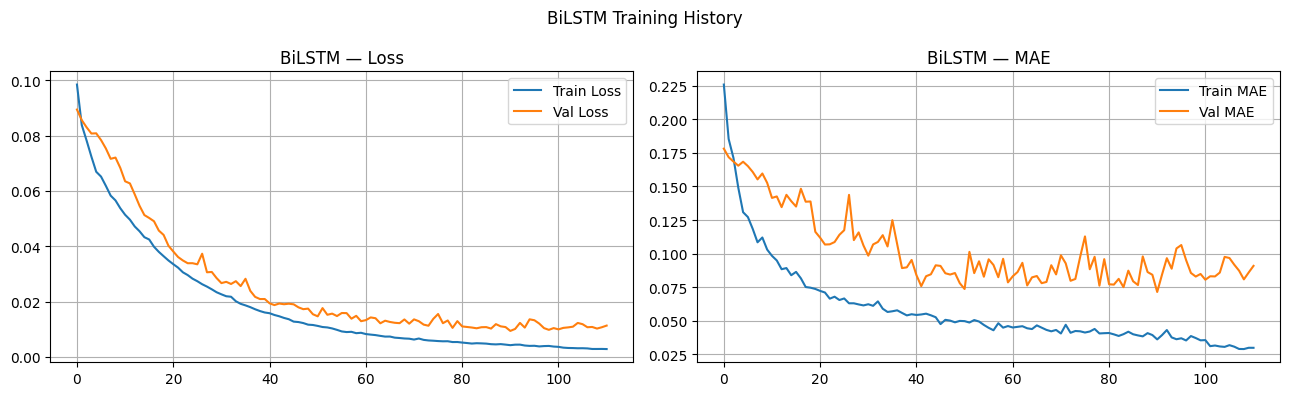

In [ ]:
model_bilstm.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])

history_bilstm = model_bilstm.fit(
    [X_seq_train, X_future_train], y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_future_test], y_test),
    callbacks=make_callbacks('BiLSTM'), verbose=1
)
plot_history(history_bilstm, 'BiLSTM')


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
BiLSTM                RMSE: 1,784,653.77  |  MAE: 1,107,453.71  |  MAPE:      106.76%  |  R2:         0.70


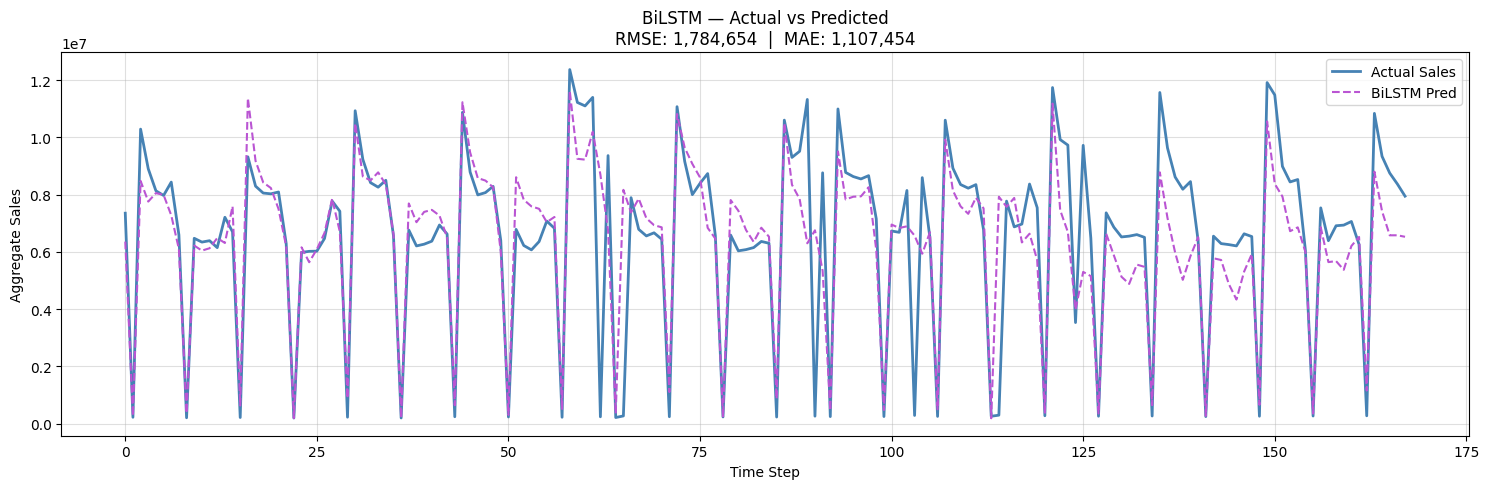

In [ ]:
y_pred_bilstm_scaled = model_bilstm.predict([X_seq_test, X_future_test])
y_pred_bilstm, rmse_bilstm, mae_bilstm, mape_bilstm, r2_bilstm = evaluate_model('BiLSTM', y_test_raw, y_pred_bilstm_scaled, target_scaler)
results['BiLSTM'] = {"y_pred": y_pred_bilstm, "RMSE": rmse_bilstm, "MAE": mae_bilstm, "MAPE": mape_bilstm, "R2": r2_bilstm}
plot_predictions(y_test_raw, y_pred_bilstm, 'BiLSTM', 'mediumorchid', rmse_bilstm, mae_bilstm)


---
## 🟠 MODEL 4 — GRU

> 128→64 units, BatchNorm, Huber loss.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

seq_input = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='seq_input')
x = GRU(128, return_sequences=True, kernel_regularizer=l2(1e-4))(seq_input)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = GRU(64, return_sequences=False, kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)

future_input = Input(shape=(N_FUTURE_FEATS,), name='future_input')
combined = layers.Concatenate()([x, future_input])
out = Dense(1, activation='sigmoid')(combined)

model_gru = Model(inputs=[seq_input, future_input], outputs=out, name='GRU_Model')
model_gru.summary()


Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ (None, 60, 128)   │     58,368 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ gru_4[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_65          │ (None, 60, 128)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_5 (GRU)         │ (None, 64)        │     37,248 │ dropout_65[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ gru_5[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_66          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_81 (Dense)    │ (None, 32)        │      2,080 │ dropout_66[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_14      │ (None, 35)        │          0 │ dense_81[0][0],   │
│ (Concatenate)       │                   │            │ future_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_82 (Dense)    │ (None, 1)         │         36 │ concatenate_14[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 98,500 (384.77 KB)

 Trainable params: 98,116 (383.27 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0640 - mae: 0.2339 - val_loss: 0.0447 - val_mae: 0.1580 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0410 - mae: 0.1734 - val_loss: 0.0432 - val_mae: 0.1549 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0363 - mae: 0.1583 - val_loss: 0.0428 - val_mae: 0.1551 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0320 - mae: 0.1405 - val_loss: 0.0416 - val_mae: 0.1536 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0288 - mae: 0.1272 - val_loss: 0.0402 - val_mae: 0.1533 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0282 - mae: 0.1322 - val_loss: 0.0392 - val_mae: 0.1523 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0257 - mae: 0.1207 - val_loss: 0.0354 - val_mae: 0.1463 - learning_rate: 0.0010
Epoch 

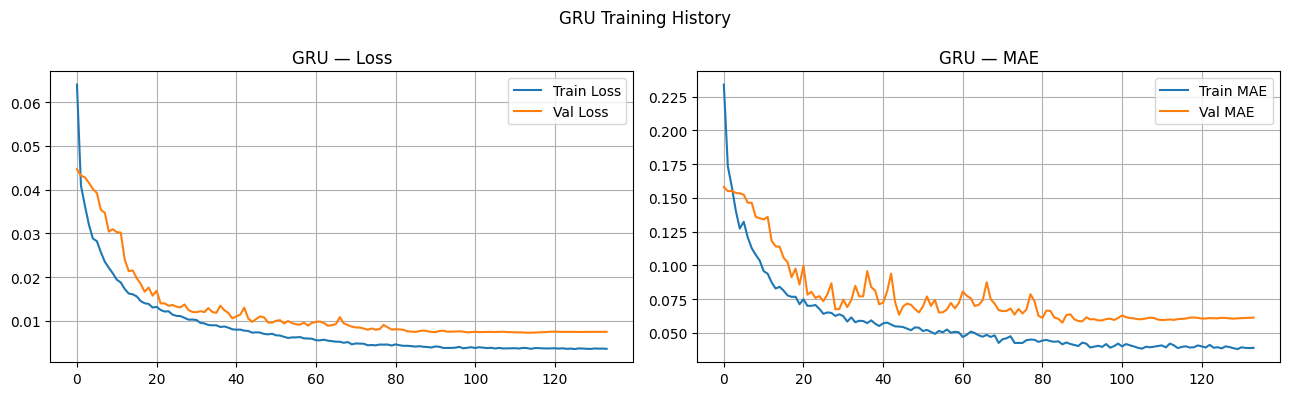

In [ ]:
model_gru.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])

history_gru = model_gru.fit(
    [X_seq_train, X_future_train], y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_future_test], y_test),
    callbacks=make_callbacks('GRU'), verbose=1
)
plot_history(history_gru, 'GRU')


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
GRU                   RMSE: 1,584,885.04  |  MAE:   923,461.29  |  MAPE:       86.58%  |  R2:         0.76


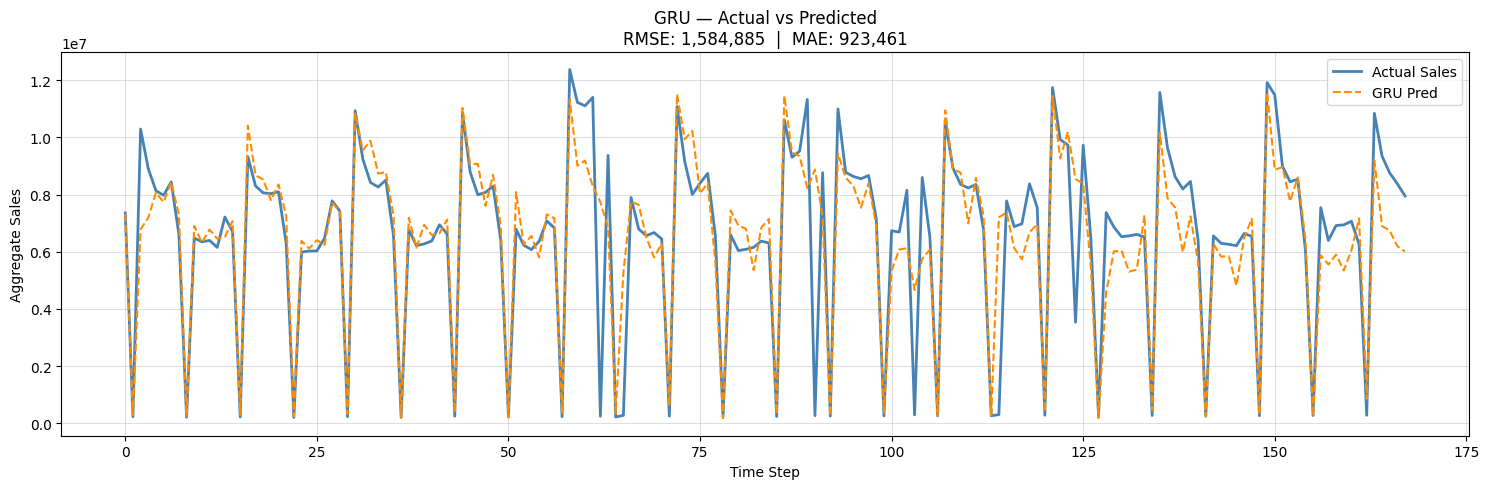

In [ ]:
y_pred_gru_scaled = model_gru.predict([X_seq_test, X_future_test])
y_pred_gru, rmse_gru, mae_gru, mape_gru, r2_gru = evaluate_model('GRU', y_test_raw, y_pred_gru_scaled, target_scaler)
results['GRU'] = {"y_pred": y_pred_gru, "RMSE": rmse_gru, "MAE": mae_gru, "MAPE": mape_gru, "R2": r2_gru}
plot_predictions(y_test_raw, y_pred_gru, 'GRU', 'darkorange', rmse_gru, mae_gru)


In [ ]:
prediction_date_str = '2013-05-15'
prediction_date = pd.to_datetime(prediction_date_str)

dates_in_final_df = aggregated_df_cleaned.dropna().index
idx_for_sales_of_prediction_date = dates_in_final_df.get_loc(prediction_date)
target_index_for_prediction = idx_for_sales_of_prediction_date - 1

if target_index_for_prediction < WINDOW_SIZE - 1:
    print(f"Error: Not enough historical data ({WINDOW_SIZE} days) to make a prediction for {prediction_date_str}.")
else:
    features_for_window = features_scaled[
        target_index_for_prediction - WINDOW_SIZE + 1 : target_index_for_prediction + 1]
    X_pred_seq_gru = features_for_window.reshape(1, WINDOW_SIZE, features_scaled.shape[1])

    # Future features at prediction date (index = target_index_for_prediction + 1 in df)
    future_idx = target_index_for_prediction + 1
    X_pred_future_gru = future_features_scaled[future_idx].reshape(1, N_FUTURE_FEATS)

    y_pred_gru_scaled_single = model_gru.predict([X_pred_seq_gru, X_pred_future_gru])
    predicted_sales_gru = target_scaler.inverse_transform(y_pred_gru_scaled_single).flatten()[0]
    actual_sales_for_date = aggregated_df_cleaned.loc[prediction_date, 'Sales']

    print(f"Predicted sales for {prediction_date_str} (GRU): {predicted_sales_gru:,.2f}")
    print(f"Actual sales for {prediction_date_str}:    {actual_sales_for_date:,.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted sales for 2013-05-15 (GRU): 7,256,437.00
Actual sales for 2013-05-15:    7,767,784.00


In [ ]:
# Save GRU point model
model_gru.save(SAVE_PATH + "gru_model.h5")
model_gru.save(SAVE_PATH + "gru_model.keras")
with open(SAVE_PATH + "gru_model.pkl", "wb") as f:
    pickle.dump(model_gru, f)

---
## 🟣 MODEL 5 — Transformer

> `num_heads=4`, Huber loss, extra Dense layer in FFN.

In [ ]:
class TransformerEncoderBlock(layers.Layer):
    """Multi-Head Attention + Feed-Forward with residual connections."""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kw):
        super().__init__(**kw)
        self.att  = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn  = keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dropout(dropout),
            Dense(embed_dim)
        ])
        self.ln1  = LayerNormalization(epsilon=1e-6)
        self.ln2  = LayerNormalization(epsilon=1e-6)
        self.do1  = Dropout(dropout)
        self.do2  = Dropout(dropout)

    def call(self, x, training=False):
        attn = self.att(x, x)
        x    = self.ln1(x + self.do1(attn, training=training))
        ffn  = self.ffn(x, training=training)
        return self.ln2(x + self.do2(ffn, training=training))

tf.random.set_seed(SEED); np.random.seed(SEED)

EMBED_DIM = 64; NUM_HEADS = 4; FF_DIM = 128; NUM_BLOCKS = 2

seq_input = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='seq_input')
x = Dense(EMBED_DIM)(seq_input)
for _ in range(NUM_BLOCKS):
    x = TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, FF_DIM, dropout=0.1)(x)
x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)

future_input = Input(shape=(N_FUTURE_FEATS,), name='future_input')
combined = layers.Concatenate()([x, future_input])
out = Dense(1, activation='sigmoid')(combined)

model_transformer = Model(inputs=[seq_input, future_input], outputs=out, name='Transformer')
model_transformer.summary()


Model: "Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_83 (Dense)    │ (None, 60, 64)    │      1,472 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 60, 64)    │     33,472 │ dense_83[0][0]    │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 60, 64)    │     33,472 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ transformer_enco… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_88 (Dense)    │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_75          │ (None, 64)        │          0 │ dense_88[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_89 (Dense)    │ (None, 32)        │      2,080 │ dropout_75[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_15      │ (None, 35)        │          0 │ dense_89[0][0],   │
│ (Concatenate)       │                   │            │ future_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_90 (Dense)    │ (None, 1)         │         36 │ concatenate_15[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 74,692 (291.77 KB)

 Trainable params: 74,692 (291.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 24s 542ms/step - loss: 0.0254 - mae: 0.1705 - val_loss: 0.0248 - val_mae: 0.1935 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0206 - mae: 0.1490 - val_loss: 0.0284 - val_mae: 0.2178 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0207 - mae: 0.1505 - val_loss: 0.0253 - val_mae: 0.1992 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0205 - mae: 0.1471 - val_loss: 0.0226 - val_mae: 0.1739 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0197 - mae: 0.1456 - val_loss: 0.0246 - val_mae: 0.1944 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0197 - mae: 0.1445 - val_loss: 0.0234 - val_mae: 0.1847 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0194 - mae: 0.1442 - val_loss: 0.0233 - val_mae: 0.1860 - learning_rate: 0.0010
Epoc

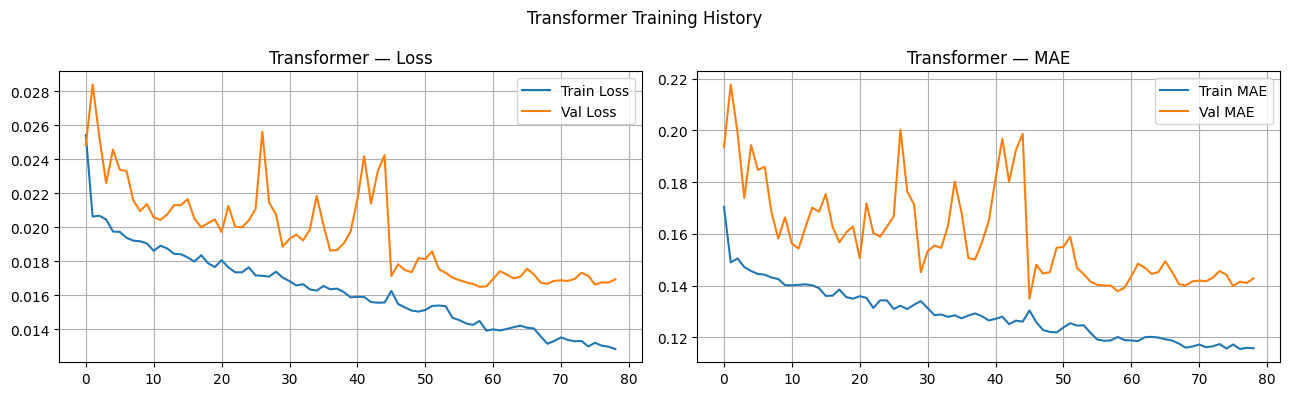

In [ ]:
model_transformer.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])

history_transformer = model_transformer.fit(
    [X_seq_train, X_future_train], y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_future_test], y_test),
    callbacks=make_callbacks('Transformer'), verbose=1
)
plot_history(history_transformer, 'Transformer')


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 259ms/step
Transformer           RMSE: 2,816,697.27  |  MAE: 2,136,966.56  |  MAPE:      331.48%  |  R2:         0.25


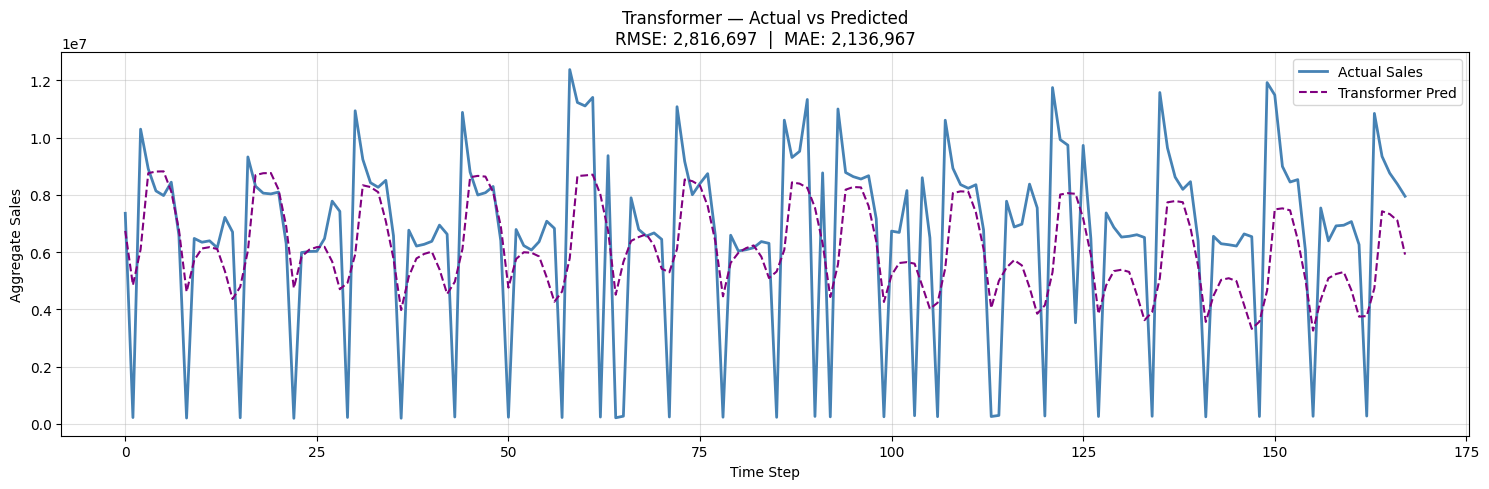

In [ ]:
y_pred_transformer_scaled = model_transformer.predict([X_seq_test, X_future_test])
y_pred_transformer, rmse_transformer, mae_transformer, mape_transformer, r2_transformer = evaluate_model(
    'Transformer', y_test_raw, y_pred_transformer_scaled, target_scaler)
results['Transformer'] = {"y_pred": y_pred_transformer, "RMSE": rmse_transformer, "MAE": mae_transformer, "MAPE": mape_transformer, "R2": r2_transformer}
plot_predictions(y_test_raw, y_pred_transformer, 'Transformer', 'purple', rmse_transformer, mae_transformer)


---
## 🔴 MODEL 6 — Temporal Convolutional Network (TCN)

> Huber loss, BatchNorm in residual block, extra dilation level.

In [ ]:
class TCNBlock(Model):
    """Dilated causal Conv1D residual block with optional skip connection."""
    def __init__(self, filters, kernel_size, dilation_rate, dropout=0.2, **kw):
        super().__init__(**kw)
        self.conv1  = Conv1D(filters, kernel_size, padding='causal',
                             dilation_rate=dilation_rate, activation='relu')
        self.bn1    = BatchNormalization()
        self.drop1  = Dropout(dropout)
        self.conv2  = Conv1D(filters, kernel_size, padding='causal',
                             dilation_rate=dilation_rate, activation='relu')
        self.bn2    = BatchNormalization()
        self.drop2  = Dropout(dropout)
        self.skip   = Conv1D(filters, 1)

    def call(self, x, training=False):
        res = self.skip(x)
        out = self.conv1(x)
        out = self.bn1(out, training=training)
        out = self.drop1(out, training=training)
        out = self.conv2(out)
        out = self.bn2(out, training=training)
        out = self.drop2(out, training=training)
        return Activation('relu')(out + res)

tf.random.set_seed(SEED); np.random.seed(SEED)

FILTERS = 64; KERNEL  = 3; DILATIONS = [1, 2, 4, 8, 16]

seq_input = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='seq_input')
x = seq_input
for d in DILATIONS:
    x = TCNBlock(FILTERS, KERNEL, dilation_rate=d, dropout=0.2)(x)
x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

future_input = Input(shape=(N_FUTURE_FEATS,), name='future_input')
combined = layers.Concatenate()([x, future_input])
out = Dense(1, activation='sigmoid')(combined)

model_tcn = Model(inputs=[seq_input, future_input], outputs=out, name='TCN_Model')
model_tcn.summary()


Model: "TCN_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_5         │ (None, 60, 64)    │     18,624 │ seq_input[0][0]   │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_6         │ (None, 60, 64)    │     29,376 │ tcn_block_5[0][0] │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_7         │ (None, 60, 64)    │     29,376 │ tcn_block_6[0][0] │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_8         │ (None, 60, 64)    │     29,376 │ tcn_block_7[0][0] │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_9         │ (None, 60, 64)    │     29,376 │ tcn_block_8[0][0] │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ tcn_block_9[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_91 (Dense)    │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_86          │ (None, 64)        │          0 │ dense_91[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_16      │ (None, 67)        │          0 │ dropout_86[0][0], │
│ (Concatenate)       │                   │            │ future_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_92 (Dense)    │ (None, 1)         │         68 │ concatenate_16[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 140,356 (548.27 KB)

 Trainable params: 139,076 (543.27 KB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 35s 732ms/step - loss: 0.0206 - mae: 0.1493 - val_loss: 0.0220 - val_mae: 0.1370 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0188 - mae: 0.1396 - val_loss: 0.0216 - val_mae: 0.1353 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0185 - mae: 0.1394 - val_loss: 0.0213 - val_mae: 0.1341 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0176 - mae: 0.1335 - val_loss: 0.0209 - val_mae: 0.1323 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0177 - mae: 0.1347 - val_loss: 0.0207 - val_mae: 0.1317 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0165 - mae: 0.1297 - val_loss: 0.0215 - val_mae: 0.1348 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0138 - mae: 0.1179 - val_loss: 0.0214 - val_mae: 0.1337 - learning_rate: 0.0010
Epoc

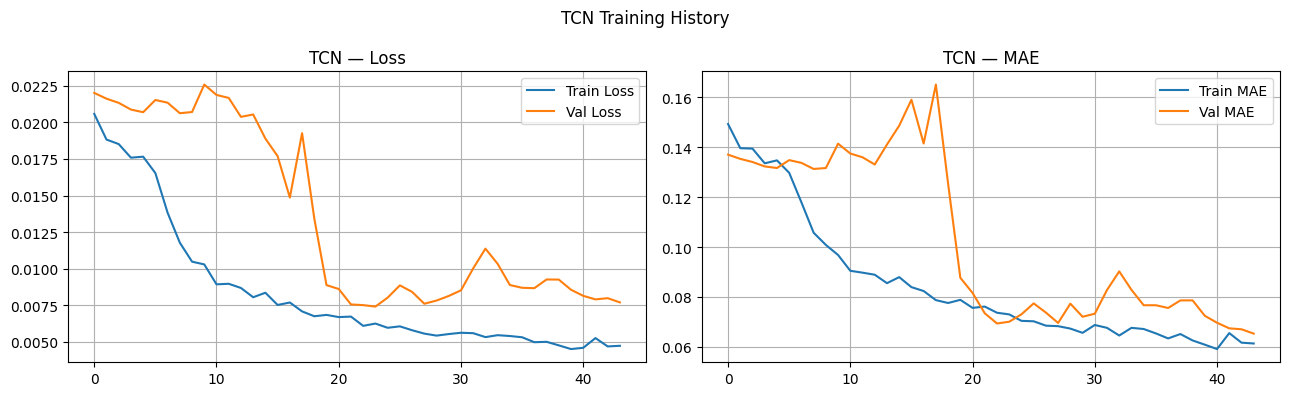

In [ ]:
model_tcn.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])

history_tcn = model_tcn.fit(
    [X_seq_train, X_future_train], y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_future_test], y_test),
    callbacks=make_callbacks('TCN'), verbose=1
)
plot_history(history_tcn, 'TCN')


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 497ms/step
TCN                   RMSE: 1,886,462.32  |  MAE: 1,086,891.02  |  MAPE:      102.55%  |  R2:         0.66


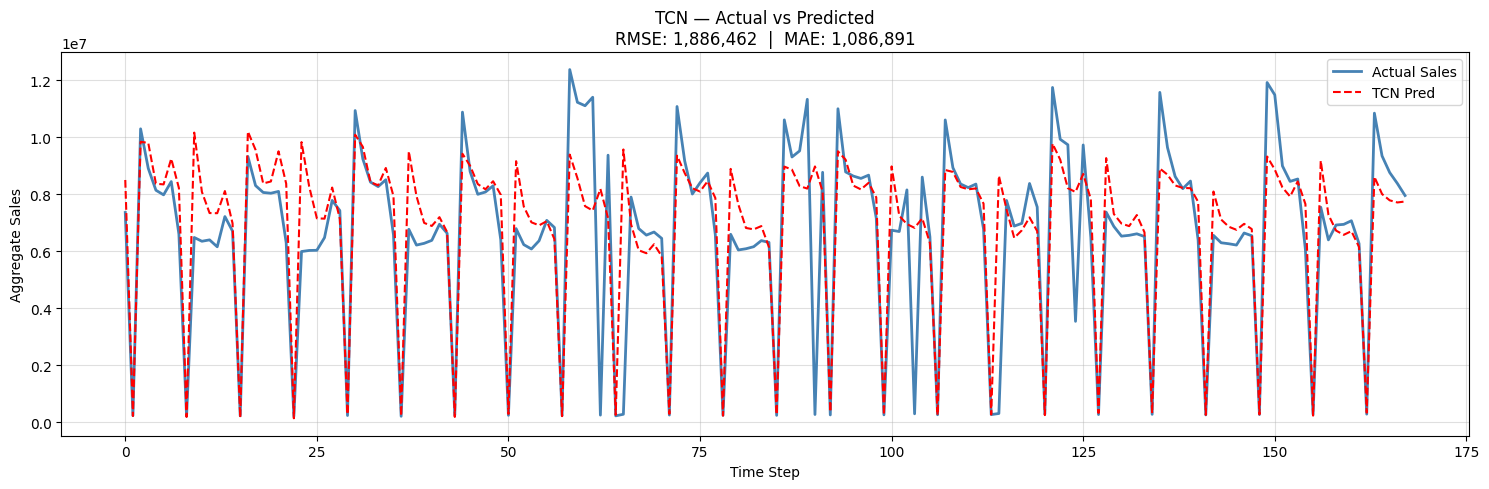

In [ ]:
y_pred_tcn_scaled = model_tcn.predict([X_seq_test, X_future_test])
y_pred_tcn, rmse_tcn, mae_tcn, mape_tcn, r2_tcn = evaluate_model('TCN', y_test_raw, y_pred_tcn_scaled, target_scaler)
results['TCN'] = {"y_pred": y_pred_tcn, "RMSE": rmse_tcn, "MAE": mae_tcn, "MAPE": mape_tcn, "R2": r2_tcn}
plot_predictions(y_test_raw, y_pred_tcn, 'TCN', 'red', rmse_tcn, mae_tcn)


---
## 🟤 MODEL 7 — N-HiTS

> Huber loss, additional pooling sizes, BatchNorm.

In [ ]:
class NHiTSBlock(layers.Layer):
    """N-HiTS block: MaxPool → Dense stack → backcast + forecast."""
    def __init__(self, input_size, forecast_size, pool_size, n_layers=2, units=256, **kw):
        super().__init__(**kw)
        self.pool = MaxPooling1D(pool_size=pool_size, strides=1, padding='same')
        mlp = []
        for _ in range(n_layers):
            mlp += [Dense(units, activation='relu'), BatchNormalization(), Dropout(0.1)]
        self.mlp        = keras.Sequential(mlp)
        self.backcast_l = Dense(input_size)
        self.forecast_l = Dense(forecast_size)

    def call(self, x, training=False):
        pooled    = self.pool(x)
        flat      = Flatten()(pooled)
        h         = self.mlp(flat, training=training)
        backcast  = self.backcast_l(h)
        forecast  = self.forecast_l(h)
        return backcast, forecast

tf.random.set_seed(SEED); np.random.seed(SEED)

INPUT_SIZE = X_seq_train.shape[1]
FEAT_DIM   = X_seq_train.shape[2]
POOL_SIZES = [2, 4, 8]

seq_input = Input(shape=(INPUT_SIZE, FEAT_DIM), name='seq_input')
residual  = Flatten()(seq_input)
forecasts = []

for ps in POOL_SIZES:
    reshaped   = layers.Reshape((INPUT_SIZE, FEAT_DIM))(
                    layers.Dense(INPUT_SIZE * FEAT_DIM)(residual)
                 )
    block      = NHiTSBlock(INPUT_SIZE * FEAT_DIM, 64, pool_size=ps, units=256)
    bc, fc     = block(reshaped)
    residual   = layers.Subtract()([residual, bc])
    forecasts.append(fc)

nhits_add  = layers.Add()(forecasts)
x          = Dense(64, activation='relu')(nhits_add)
x          = Dropout(0.2)(x)

future_input = Input(shape=(N_FUTURE_FEATS,), name='future_input')
combined = layers.Concatenate()([x, future_input])
out = Dense(1, activation='sigmoid')(combined)

model_nhits = Model(inputs=[seq_input, future_input], outputs=out, name='NHiTS_Model')
model_nhits.summary()


Model: "NHiTS_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_44          │ (None, 1320)      │          0 │ seq_input[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_93 (Dense)    │ (None, 1320)      │  1,743,720 │ flatten_44[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 60, 22)    │          0 │ dense_93[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n_hi_ts_block_6     │ [(None, 1320),    │    761,704 │ reshape_6[0][0]   │
│ (NHiTSBlock)        │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_6          │ (None, 1320)      │          0 │ flatten_44[0][0], │
│ (Subtract)          │                   │            │ n_hi_ts_block_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_98 (Dense)    │ (None, 1320)      │  1,743,720 │ subtract_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 60, 22)    │          0 │ dense_98[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n_hi_ts_block_7     │ [(None, 1320),    │    761,704 │ reshape_7[0][0]   │
│ (NHiTSBlock)        │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_7          │ (None, 1320)      │          0 │ subtract_6[0][0], │
│ (Subtract)          │                   │            │ n_hi_ts_block_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_103 (Dense)   │ (None, 1320)      │  1,743,720 │ subtract_7[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 60, 22)    │          0 │ dense_103[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n_hi_ts_block_8     │ [(None, 1320),    │    761,704 │ reshape_8[0][0]   │
│ (NHiTSBlock)        │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 64)        │          0 │ n_hi_ts_block_6[… │
│                     │                   │            │ n_hi_ts_block_7[… │
│                     │                   │            │ n_hi_ts_block_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_108 (Dense)   │ (None, 64)        │      4,160 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_93          │ (None, 64)        │          0 │ dense_108[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_17      │ (None, 67)        │          0 │ dropout_93[0][0], │
│ (Concatenate)       │                   │            │ future_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_109 (Dense)   │ (None, 1)         │         68 │ concatenate_17[0

 Total params: 7,520,500 (28.69 MB)

 Trainable params: 7,517,428 (28.68 MB)

 Non-trainable params: 3,072 (12.00 KB)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 355ms/step - loss: 0.0575 - mae: 0.2760 - val_loss: 0.1088 - val_mae: 0.4164 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0395 - mae: 0.2216 - val_loss: 0.1088 - val_mae: 0.4164 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0295 - mae: 0.1861 - val_loss: 0.1088 - val_mae: 0.4164 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0207 - mae: 0.1521 - val_loss: 0.1088 - val_mae: 0.4164 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0140 - mae: 0.1196 - val_loss: 0.1088 - val_mae: 0.4164 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0105 - mae: 0.1015 - val_loss: 0.1088 - val_mae: 0.4164 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0095 - mae: 0.0910 - val_loss: 0.1012 - val_mae: 0.4017 - learning_rate: 0.0010
Epoc

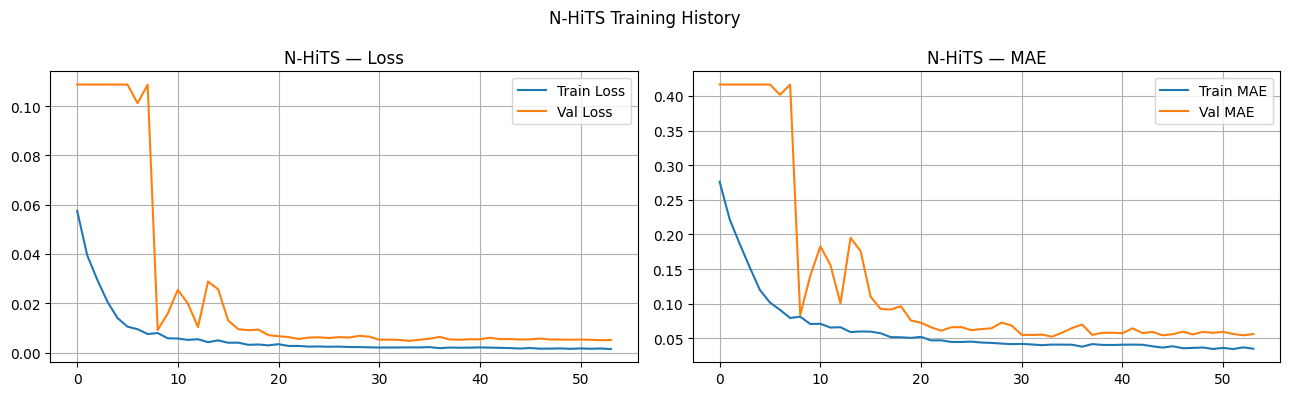

In [ ]:
model_nhits.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])

history_nhits = model_nhits.fit(
    [X_seq_train, X_future_train], y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_future_test], y_test),
    callbacks=make_callbacks('N-HiTS'), verbose=1
)
plot_history(history_nhits, 'N-HiTS')


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step
N-HiTS                RMSE: 1,509,555.41  |  MAE:   809,719.96  |  MAPE:       88.93%  |  R2:         0.79


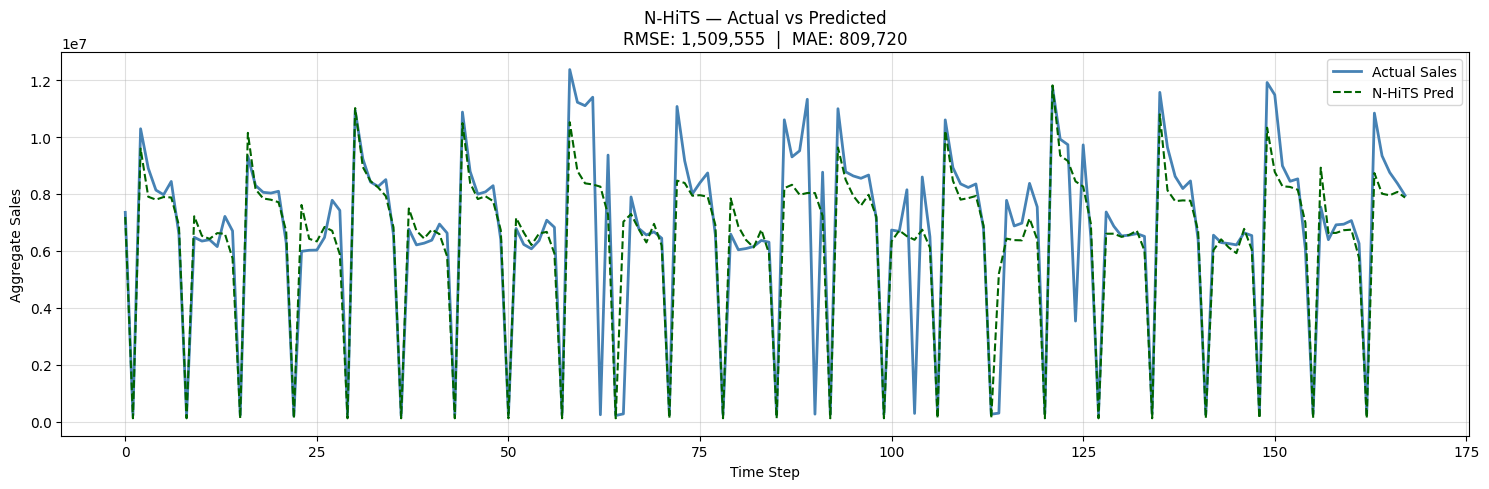

In [ ]:
y_pred_nhits_scaled = model_nhits.predict([X_seq_test, X_future_test])
y_pred_nhits, rmse_nhits, mae_nhits, mape_nhits, r2_nhits = evaluate_model('N-HiTS', y_test_raw, y_pred_nhits_scaled, target_scaler)
results['N-HiTS'] = {"y_pred": y_pred_nhits, "RMSE": rmse_nhits, "MAE": mae_nhits, "MAPE": mape_nhits, "R2": r2_nhits}
plot_predictions(y_test_raw, y_pred_nhits, 'N-HiTS', 'darkgreen', rmse_nhits, mae_nhits)


### Saving Scalers

In [ ]:
# Save feature_scaler
with open(SAVE_PATH + "feature_scaler.pkl", "wb") as f:
    pickle.dump(feature_scaler, f)

# Save target_scaler
with open(SAVE_PATH + "target_scaler.pkl", "wb") as f:
    pickle.dump(target_scaler, f)

# Save future_scaler
with open(SAVE_PATH + "future_scaler.pkl", "wb") as f:
    pickle.dump(future_scaler, f)

print("✅ feature_scaler, target_scaler, future_scaler saved.")


✅ feature_scaler, target_scaler, future_scaler saved.


In [ ]:
# Save N-HiTS point model
model_nhits.save(SAVE_PATH + "nhits_model.h5")
model_nhits.save(SAVE_PATH + "nhits_model.keras")
with open(SAVE_PATH + "nhits_model.pkl", "wb") as f:
    pickle.dump(model_nhits, f)

---
## 🩵 MODEL 8 — PatchTST

> Huber loss, patch stride = patch_len // 2 for overlap.

In [ ]:
PATCH_LEN    = 12
PATCH_STRIDE = 6
D_MODEL      = 64
N_HEADS      = 4
FF_DIM_P     = 128
N_LAYERS_P   = 2
DROPOUT_P    = 0.1

def make_patches(x, patch_len, stride):
    """Slice (batch, time, feat) → (batch, n_patches, patch_len*feat)."""
    seqs = []
    for start in range(0, x.shape[1] - patch_len + 1, stride):
        seqs.append(x[:, start:start + patch_len, :])
    patches = tf.stack(seqs, axis=1)
    B, N, P, F = patches.shape
    return tf.reshape(patches, [-1, N, P * F])

tf.random.set_seed(SEED); np.random.seed(SEED)

seq_input = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='seq_input')
patches   = layers.Lambda(lambda x: make_patches(x, PATCH_LEN, PATCH_STRIDE))(seq_input)
x         = Dense(D_MODEL)(patches)

for _ in range(N_LAYERS_P):
    attn = MultiHeadAttention(num_heads=N_HEADS, key_dim=D_MODEL // N_HEADS)(x, x)
    x    = LayerNormalization()(x + Dropout(DROPOUT_P)(attn))
    ffn  = keras.Sequential([Dense(FF_DIM_P, activation='gelu'), Dense(D_MODEL)])(x)
    x    = LayerNormalization()(x + Dropout(DROPOUT_P)(ffn))

x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

future_input = Input(shape=(N_FUTURE_FEATS,), name='future_input')
combined = layers.Concatenate()([x, future_input])
out = Dense(1, activation='sigmoid')(combined)

model_patchtst = Model(inputs=[seq_input, future_input], outputs=out, name='PatchTST')
model_patchtst.summary()


Model: "PatchTST"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 9, 264)    │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_110 (Dense)   │ (None, 9, 64)     │     16,960 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 64)     │     16,640 │ dense_110[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dense_110[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_95          │ (None, 9, 64)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 9, 64)     │          0 │ dense_110[0][0],  │
│                     │                   │            │ dropout_95[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 64)     │        128 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_15       │ (None, 9, 64)     │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_96          │ (None, 9, 64)     │          0 │ sequential_15[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 9, 64)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_96[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 64)     │        128 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 64)     │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_98          │ (None, 9, 64)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 9, 64)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_98[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 64)     │        128 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_16       │ (None, 9, 64)     │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_99          │ (None, 9, 64)     │          0 │ sequential_16[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 88,132 (344.27 KB)

 Trainable params: 88,132 (344.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 388ms/step - loss: 0.0239 - mae: 0.1671 - val_loss: 0.0197 - val_mae: 0.1530 - learning_rate: 5.0000e-04
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0181 - mae: 0.1380 - val_loss: 0.0220 - val_mae: 0.1796 - learning_rate: 5.0000e-04
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0176 - mae: 0.1357 - val_loss: 0.0207 - val_mae: 0.1702 - learning_rate: 5.0000e-04
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0168 - mae: 0.1327 - val_loss: 0.0205 - val_mae: 0.1710 - learning_rate: 5.0000e-04
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0157 - mae: 0.1292 - val_loss: 0.0220 - val_mae: 0.1833 - learning_rate: 5.0000e-04
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0150 - mae: 0.1282 - val_loss: 0.0220 - val_mae: 0.1847 - learning_rate: 5.0000e-04
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0143 - mae: 0.1270 - val_loss: 0.0168 - val_mae: 0.1524 - learning

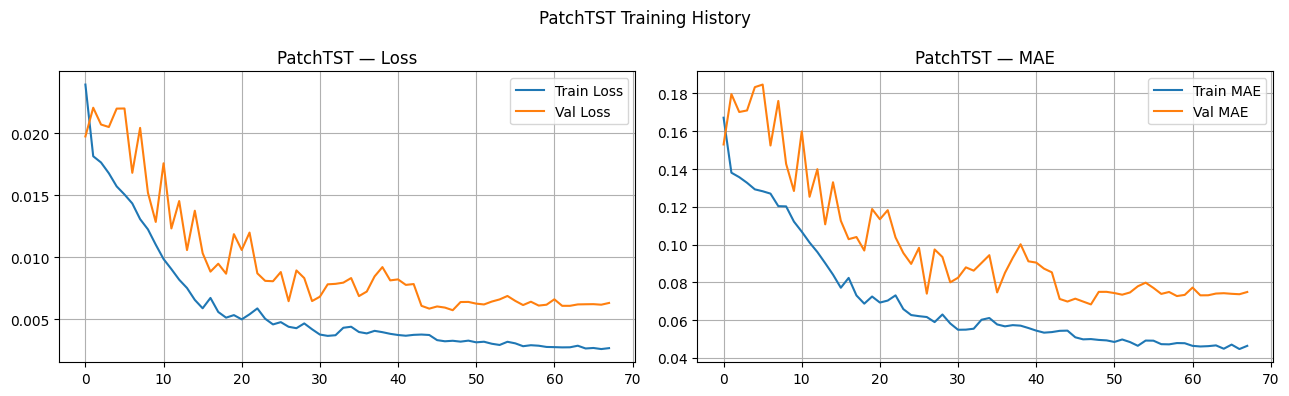

In [ ]:
model_patchtst.compile(optimizer=Adam(5e-4), loss='huber', metrics=['mae'])

history_patchtst = model_patchtst.fit(
    [X_seq_train, X_future_train], y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_future_test], y_test),
    callbacks=make_callbacks('PatchTST'), verbose=1
)
plot_history(history_patchtst, 'PatchTST')


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 295ms/step
PatchTST              RMSE: 1,658,675.15  |  MAE: 1,059,706.30  |  MAPE:       82.05%  |  R2:         0.74


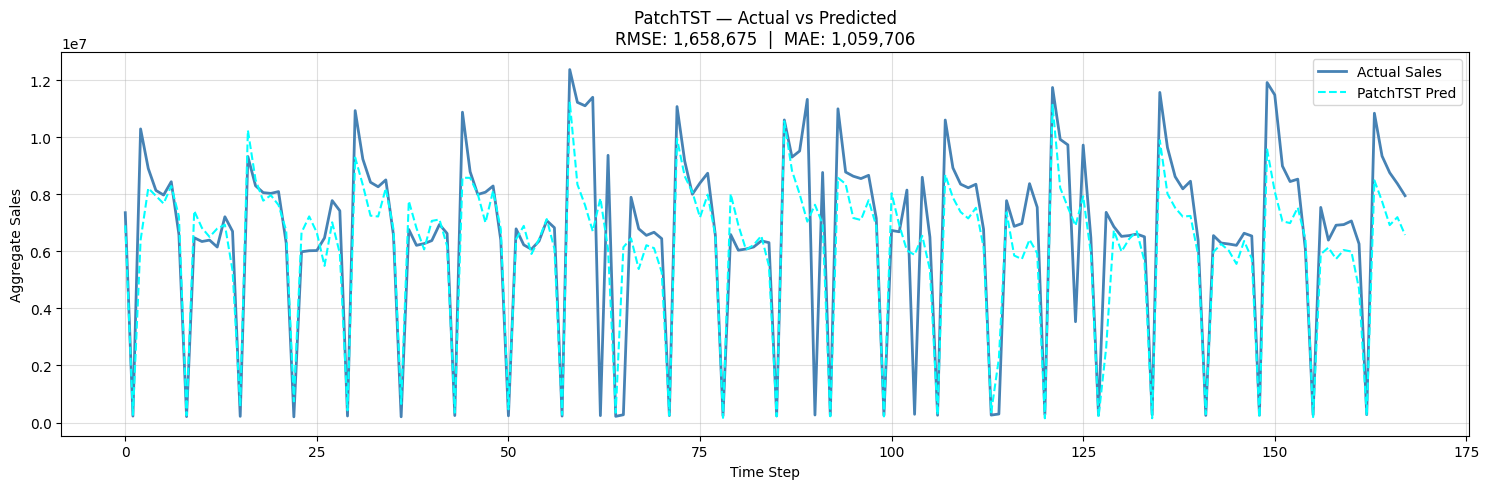

In [ ]:
y_pred_patchtst_scaled = model_patchtst.predict([X_seq_test, X_future_test])
y_pred_patchtst, rmse_patchtst, mae_patchtst, mape_patchtst, r2_patchtst = evaluate_model(
    'PatchTST', y_test_raw, y_pred_patchtst_scaled, target_scaler)
results['PatchTST'] = {"y_pred": y_pred_patchtst, "RMSE": rmse_patchtst, "MAE": mae_patchtst, "MAPE": mape_patchtst, "R2": r2_patchtst}
plot_predictions(y_test_raw, y_pred_patchtst, 'PatchTST', 'cyan', rmse_patchtst, mae_patchtst)


---
## 🟦 MODEL 9 — Amazon Chronos (`amazon/chronos-2`)

> Foundation model; no training required. Uses median quantile (0.5) as point forecast.

In [ ]:
import sys
!{sys.executable} -m pip install "chronos-forecasting>=2.0" -q

In [ ]:
from chronos import Chronos2Pipeline

df_chronos              = df.copy()
df_chronos['id']        = 'sales_series'
df_chronos['timestamp'] = df_chronos.index
df_chronos['target']    = df_chronos['Sales']
df_chronos              = df_chronos[['id', 'timestamp', 'target']]

split_c = int(len(df_chronos) * SPLIT_RATIO)
train_df_chronos = df_chronos.iloc[:split_c].copy()
test_df_chronos  = df_chronos.iloc[split_c:].copy()
future_df        = test_df_chronos[['id', 'timestamp']].copy()

print(f"Context: {train_df_chronos.shape}  Future: {future_df.shape}")

Context: (717, 3)  Future: (180, 2)


In [ ]:
pipeline = Chronos2Pipeline.from_pretrained(
    'amazon/chronos-t5-small',
    device_map='cuda'
)
print('Chronos2Pipeline loaded ✅')

Chronos2Pipeline loaded ✅


Chronos               RMSE: 4,551,424.02  |  MAE: 3,556,542.56  |  MAPE:      590.37%  |  R2:        -0.95


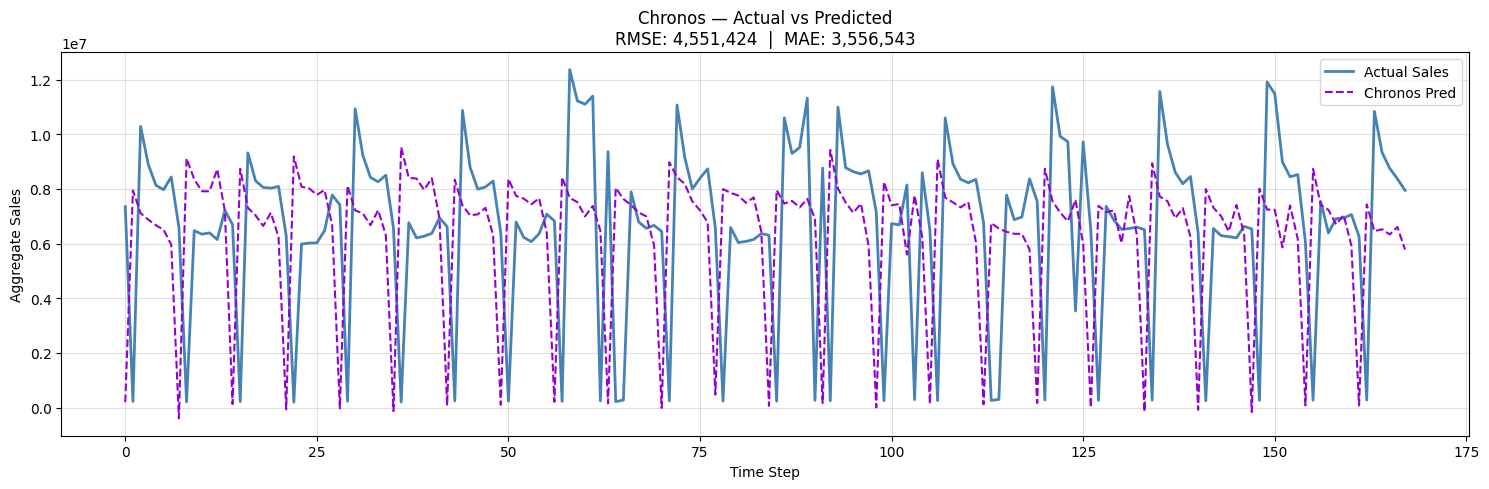

In [ ]:
pred_df_chronos = pipeline.predict_df(
    train_df_chronos,
    future_df=future_df,
    prediction_length=len(test_df_chronos),
    quantile_levels=[0.1, 0.5, 0.9],
    id_column='id', timestamp_column='timestamp', target='target',
)

y_pred_chronos = pred_df_chronos['0.5'].values
if len(y_pred_chronos) != len(y_test_raw):
    y_pred_chronos = y_pred_chronos[:len(y_test_raw)]

rmse_chronos = np.sqrt(mean_squared_error(y_test_raw, y_pred_chronos))
mae_chronos  = mean_absolute_error(y_test_raw, y_pred_chronos)
mape_chronos = mean_absolute_percentage_error(y_test_raw + 1e-8, y_pred_chronos) # Handle MAPE instability
r2_chronos   = r2_score(y_test_raw, y_pred_chronos)
print(f"{'Chronos':20s}  RMSE: {rmse_chronos:>12,.2f}  |  MAE: {mae_chronos:>12,.2f}  |  MAPE: {mape_chronos:>12.2%}  |  R2: {r2_chronos:>12.2f}")
results['Chronos'] = {"y_pred": y_pred_chronos, "RMSE": rmse_chronos, "MAE": mae_chronos, "MAPE": mape_chronos, "R2": r2_chronos}
plot_predictions(y_test_raw, y_pred_chronos, 'Chronos', 'darkviolet', rmse_chronos, mae_chronos)

---
## 📊 PART 1 FINAL — Point Model Comparison & All-in-One Chart

In [ ]:
comparison = pd.DataFrame([
    {'Model': name, 'RMSE': metrics['RMSE'], 'MAE': metrics['MAE'], 'MAPE': metrics['MAPE'], 'R2': metrics['R2']}
    for name, metrics in results.items()
]).sort_values('RMSE').reset_index(drop=True)

comparison['RMSE_rank'] = comparison['RMSE'].rank().astype(int)

print('\n📊 Point Model Comparison (lower RMSE/MAE/MAPE, higher R2 is better):')
display(comparison.style
    .format({'RMSE': '{:,.2f}', 'MAE': '{:,.2f}', 'MAPE': '{:.2%}', 'R2': '{:,.2f}'})
    .background_gradient(subset=['RMSE','MAE', 'MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2'], cmap='RdYlGn'))


📊 Point Model Comparison (lower RMSE/MAE/MAPE, higher R2 is better):


,Model,RMSE,MAE,MAPE,R2,RMSE_rank
0,FNN,"1,427,675.12","894,281.62",69.60%,0.81,1
1,N-HiTS,"1,509,555.41","809,719.96",88.93%,0.79,2
2,LSTM,"1,537,578.37","881,887.43",83.42%,0.78,3
3,SimpleRNN,"1,543,141.64","868,216.34",86.89%,0.78,4
4,GRU,"1,584,885.04","923,461.29",86.58%,0.76,5
5,PatchTST,"1,658,675.15","1,059,706.30",82.05%,0.74,6
6,BiLSTM,"1,784,653.77","1,107,453.71",106.76%,0.70,7
7,TCN,"1,886,462.32","1,086,891.02",102.55%,0.66,8
8,Transformer,"2,816,697.27","2,136,966.56",331.48%,0.25,9
9,Chronos,"4,551,424.02","3,556,542.56",590.37%,-0.95,10


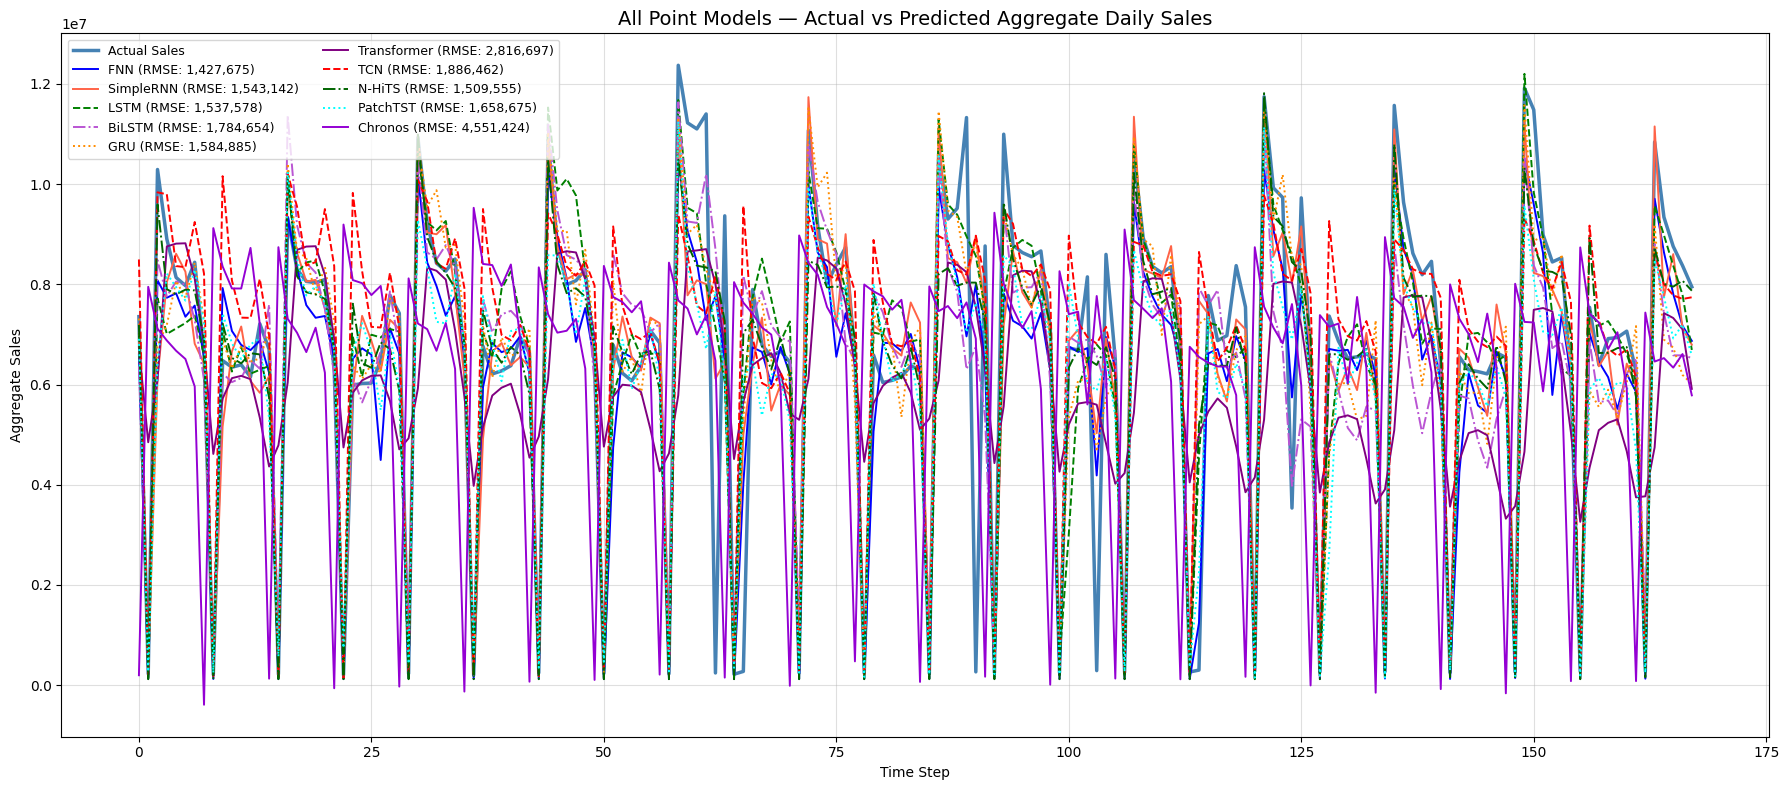

In [ ]:
COLORS = {
    'FNN': 'blue',
    'SimpleRNN': 'tomato', 'LSTM': 'green', 'BiLSTM': 'mediumorchid',
    'GRU': 'darkorange', 'Transformer': 'purple', 'TCN': 'red',
    'N-HiTS': 'darkgreen', 'PatchTST': 'cyan', 'Chronos': 'darkviolet'
}
STYLES = ['-', '-', '--','-.', ':', '-', '--','-.', ':', '-']

n = min(200, len(y_test_raw))
plt.figure(figsize=(18, 8))
plt.plot(y_test_raw[:n], label='Actual Sales', color='steelblue', lw=2.5)
for (name, metrics), ls in zip(results.items(), STYLES):
    plt.plot(metrics['y_pred'][:n], label=f'{name} (RMSE: {metrics["RMSE"]:,.0f})', color=COLORS.get(name,'gray'), lw=1.4, ls=ls)

plt.title('All Point Models — Actual vs Predicted Aggregate Daily Sales', fontsize=14)
plt.xlabel('Time Step'); plt.ylabel('Aggregate Sales')
plt.legend(fontsize=9, loc='upper left', ncol=2)
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

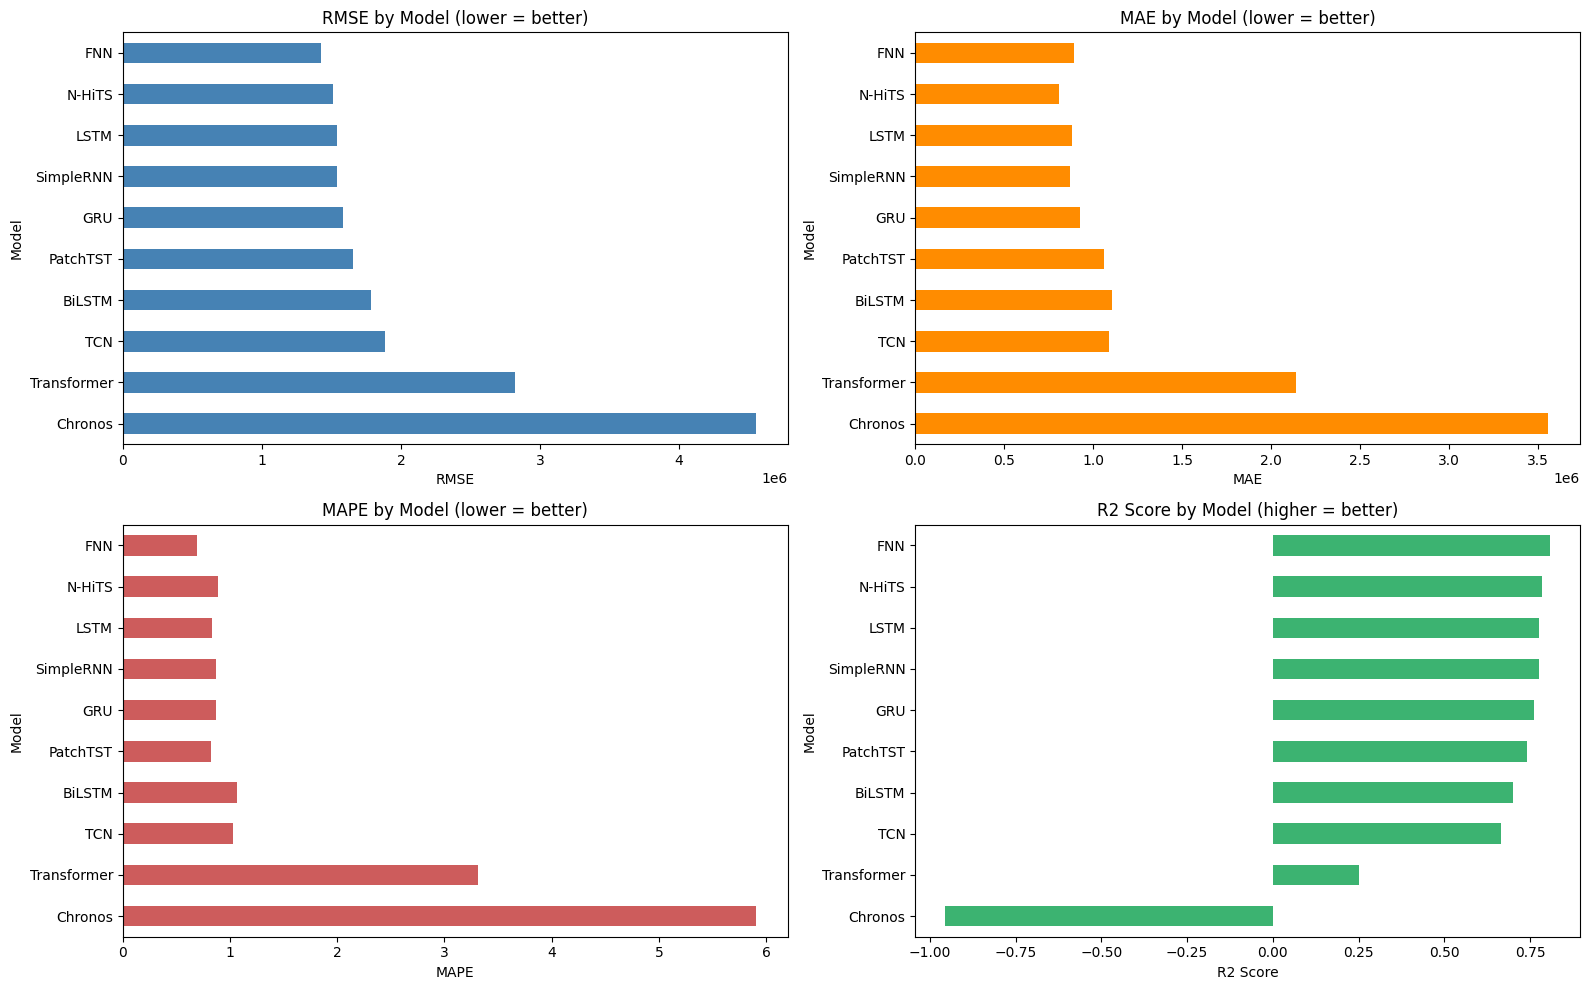


🏆 Best point model: FNN  →  RMSE: 1,427,675.12  |  MAE: 894,281.62  |  MAPE: 69.60%  |  R2: 0.81


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10)) # Adjust figsize and layout for 4 plots
axes = axes.flatten() # Flatten for easier iteration

# RMSE Plot
comparison.plot.barh(x='Model', y='RMSE', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('RMSE by Model (lower = better)'); axes[0].set_xlabel('RMSE')
axes[0].invert_yaxis()

# MAE Plot
comparison.plot.barh(x='Model', y='MAE', ax=axes[1], color='darkorange', legend=False)
axes[1].set_title('MAE by Model (lower = better)');  axes[1].set_xlabel('MAE')
axes[1].invert_yaxis()

# MAPE Plot
comparison.plot.barh(x='Model', y='MAPE', ax=axes[2], color='indianred', legend=False) # New color for MAPE
axes[2].set_title('MAPE by Model (lower = better)'); axes[2].set_xlabel('MAPE')
axes[2].invert_yaxis()

# R2 Plot
comparison.plot.barh(x='Model', y='R2', ax=axes[3], color='mediumseagreen', legend=False) # New color for R2
axes[3].set_title('R2 Score by Model (higher = better)'); axes[3].set_xlabel('R2 Score')
axes[3].invert_yaxis() # Invert for consistency in ordering, but note 'higher = better' in title

plt.tight_layout(); plt.show()

best = comparison.iloc[0]
print(f"\n🏆 Best point model: {best['Model']}  →  RMSE: {best['RMSE']:,.2f}  |  MAE: {best['MAE']:,.2f}  |  MAPE: {best['MAPE']:.2%}  |  R2: {best['R2']:,.2f}")

---

# 🔶 PART 2 — Quantile Prediction Models

> Models that output **three quantiles** [0.025, 0.5, 0.975] providing a **95% prediction interval**.
>
> **Metrics:** Pinball loss · Coverage rate · Median RMSE/MAE

## 🔧 Quantile Helper Functions

> All shared utilities for quantile training, evaluation, and visualisation are defined here **before** any quantile model is built — preventing `NameError` when cells run in order.

In [ ]:
# ── Quantile levels ──
quantiles = [0.025, 0.5, 0.975]

# ── Training loss ──
def quantile_loss(y_true, y_pred):
    """
    Pinball (quantile) loss over 3 quantiles [0.025, 0.5, 0.975].
    y_pred shape: (batch, 3)   y_true shape: (batch,)
    """
    loss = 0
    for i, q in enumerate(quantiles):
        error = y_true - y_pred[:, i]
        loss += tf.reduce_mean(tf.maximum(q * error, (q - 1) * error))
    return loss / len(quantiles)

# ── Training metric (median branch only) ──
def median_mae(y_true, y_pred):
    """
    MAE on the median prediction (index 1) so Keras tracks a meaningful
    scalar metric even though y_pred has 3 columns.
    FIX: Using a dedicated function avoids the shape-mismatch error that
    occurs when metrics=['mae'] is passed with a multi-output model.
    """
    return tf.reduce_mean(tf.abs(y_true - y_pred[:, 1]))

# ── Numpy evaluation metric ──
def pinball_loss_np(y_true, y_pred, q):
    """Numpy pinball loss for post-training evaluation."""
    error = y_true - y_pred
    return np.mean(np.maximum(q * error, (q - 1) * error))

# ── History plotting (quantile-aware) ──
def plot_quantile_history(history, model_name):
    """
    Plot train/val loss and median-MAE for quantile models.
    FIX: Uses 'median_mae' key (not 'mae') to match the custom metric name,
    preventing the KeyError: 'mae' that occurs with plot_history().
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{model_name} — Quantile Loss'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history.history['median_mae'],     label='Train Median MAE')
    axes[1].plot(history.history['val_median_mae'], label='Val Median MAE')
    axes[1].set_title(f'{model_name} — Median MAE'); axes[1].legend(); axes[1].grid(True)
    plt.suptitle(f'{model_name} Training History', fontsize=12)
    plt.tight_layout(); plt.show()

# ── Prediction interval plotting ──
def plot_quantile_predictions(y_true, q_low, q_med, q_high, model_name,
                               color, rmse, mae, coverage, points=200):
    """Plot actual vs predicted with shaded 95% confidence interval."""
    n = min(points, len(y_true))
    plt.figure(figsize=(15, 5))
    plt.plot(y_true[:n], label='Actual Sales', color='steelblue', lw=2)
    plt.plot(q_med[:n],  label=f'{model_name} Median (RMSE: {rmse:,.0f})',
             color=color, lw=1.5, ls='--')
    plt.fill_between(range(n), q_low[:n], q_high[:n],
                     color=color, alpha=0.2,
                     label=f'95% CI (Coverage: {coverage:.1%})')
    plt.title(f'{model_name} — Actual vs Quantile Predictions\n'
              f'RMSE (Median): {rmse:,.0f}  |  MAE (Median): {mae:,.0f} | Coverage: {coverage:.1%}',
              fontsize=12)
    plt.xlabel('Time Step'); plt.ylabel('Aggregate Sales')
    plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

quantile_results = {}   # {model_name: (q_med, rmse, mae)}
print("✅ All quantile helper functions defined.")

✅ All quantile helper functions defined.


---
## 🟨 QUANTILE MODEL 0 — FNN (95% Prediction Interval)

> Same architecture as Point FNN, but the **output layer produces 3 quantiles** [0.025, 0.5, 0.975]
> and is trained with **quantile / pinball loss**.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

# Flatten sequence and append known future features (same as point FNN)
X_train_flat_q = np.concatenate(
    [X_seq_train.reshape(X_seq_train.shape[0], -1), X_future_train], axis=1)
X_test_flat_q  = np.concatenate(
    [X_seq_test.reshape(X_seq_test.shape[0], -1),  X_future_test],  axis=1)

print(f"Flattened+future X_train_q shape: {X_train_flat_q.shape}")
print(f"Flattened+future X_test_q shape:  {X_test_flat_q.shape}")

model_fnn_quantile = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_flat_q.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='sigmoid')   # 3 quantiles, scaled 0-1
], name='FNN_Quantile_Model')
model_fnn_quantile.summary()


Flattened+future X_train_q shape: (669, 1323)
Flattened+future X_test_q shape:  (168, 1323)


Model: "FNN_Quantile_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_117 (Dense)               │ (None, 128)            │       169,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_101 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_102 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,907 (702.76 KB)

 Trainable params: 179,907 (702.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - loss: 0.0374 - median_mae: 0.1568 - val_loss: 0.0323 - val_median_mae: 0.1470 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0296 - median_mae: 0.1308 - val_loss: 0.0274 - val_median_mae: 0.1177 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0247 - median_mae: 0.1043 - val_loss: 0.0243 - val_median_mae: 0.1036 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0219 - median_mae: 0.0883 - val_loss: 0.0210 - val_median_mae: 0.0819 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0208 - median_mae: 0.0819 - val_loss: 0.0197 - val_median_mae: 0.0752 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0194 - median_mae: 0.0744 - val_loss: 0.0218 - val_median_mae: 0.0904 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0186 -

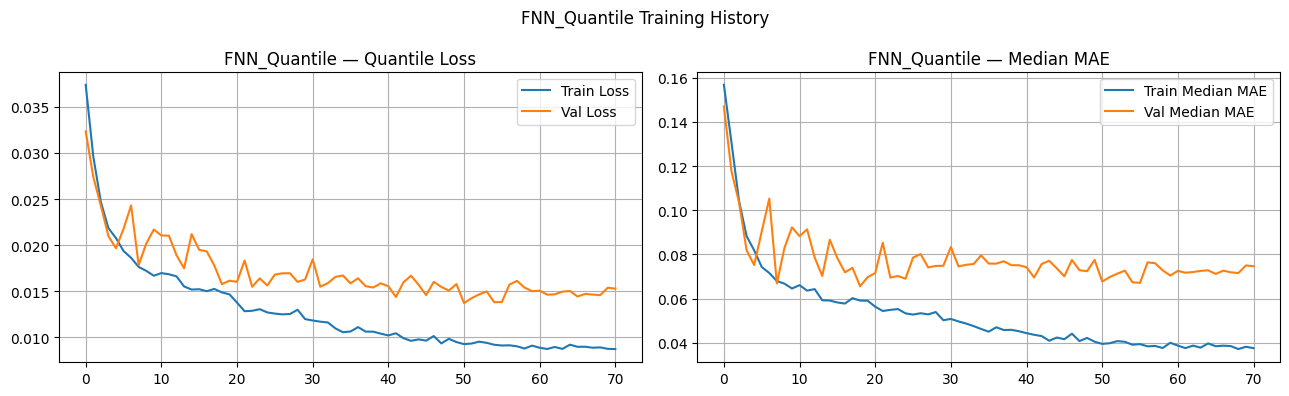

In [ ]:
# FIX: use median_mae metric (defined in quantile helpers) instead of 'mae'
# to avoid shape-mismatch error with 3-output model
model_fnn_quantile.compile(optimizer=Adam(1e-3), loss=quantile_loss, metrics=[median_mae])

history_fnn_quantile = model_fnn_quantile.fit(
    X_train_flat_q, y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_test_flat_q, y_test),
    callbacks=make_callbacks('FNN_Quantile'), verbose=1
)
# FIX: plot_quantile_history instead of plot_history (correct metric key)
plot_quantile_history(history_fnn_quantile, 'FNN_Quantile')

In [ ]:
y_pred_fnn_q_scaled = model_fnn_quantile.predict(X_test_flat_q)

q_low_scaled_fnn  = y_pred_fnn_q_scaled[:, 0]
q_med_scaled_fnn  = y_pred_fnn_q_scaled[:, 1]
q_high_scaled_fnn = y_pred_fnn_q_scaled[:, 2]

q_low_fnn  = target_scaler.inverse_transform(q_low_scaled_fnn.reshape(-1, 1)).flatten()
q_med_fnn  = target_scaler.inverse_transform(q_med_scaled_fnn.reshape(-1, 1)).flatten()
q_high_fnn = target_scaler.inverse_transform(q_high_scaled_fnn.reshape(-1, 1)).flatten()

print("✅ Quantile predictions made and inverse transformed for FNN.")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
✅ Quantile predictions made and inverse transformed for FNN.


In [ ]:
# Save FNN Quantile model
model_fnn_quantile.save(SAVE_PATH + "fnn_quantile_model.h5")
model_fnn_quantile.save(SAVE_PATH + "fnn_quantile_model.keras")
with open(SAVE_PATH + "fnn_quantile_model.pkl", "wb") as f:
    pickle.dump(model_fnn_quantile, f)

In [ ]:
loss_025_fnn = pinball_loss_np(y_test, q_low_scaled_fnn,  0.025)
loss_05_fnn  = pinball_loss_np(y_test, q_med_scaled_fnn,  0.5)
loss_975_fnn = pinball_loss_np(y_test, q_high_scaled_fnn, 0.975)
avg_pinball_fnn = (loss_025_fnn + loss_05_fnn + loss_975_fnn) / 3

print(f"Pinball Loss (q=0.025) FNN: {loss_025_fnn:.4f}")
print(f"Pinball Loss (q=0.5)   FNN: {loss_05_fnn:.4f}")
print(f"Pinball Loss (q=0.975) FNN: {loss_975_fnn:.4f}")
print(f"Average Pinball Loss   FNN: {avg_pinball_fnn:.4f}")

coverage_fnn = np.mean((y_test_raw >= q_low_fnn) & (y_test_raw <= q_high_fnn))
print(f"95% Interval Coverage  FNN: {coverage_fnn:.2%}")

rmse_fnn_q = np.sqrt(mean_squared_error(y_test_raw, q_med_fnn))
mae_fnn_q  = mean_absolute_error(y_test_raw, q_med_fnn)
print(f"FNN Quantile (Median) RMSE: {rmse_fnn_q:>12,.2f}  |  MAE: {mae_fnn_q:>12,.2f}")

quantile_results['FNN_Quantile'] = (q_med_fnn, rmse_fnn_q, mae_fnn_q, coverage_fnn)

Pinball Loss (q=0.025) FNN: 0.0061
Pinball Loss (q=0.5)   FNN: 0.0314
Pinball Loss (q=0.975) FNN: 0.0037
Average Pinball Loss   FNN: 0.0137
95% Interval Coverage  FNN: 88.69%
FNN Quantile (Median) RMSE: 1,557,074.15  |  MAE:   973,338.08


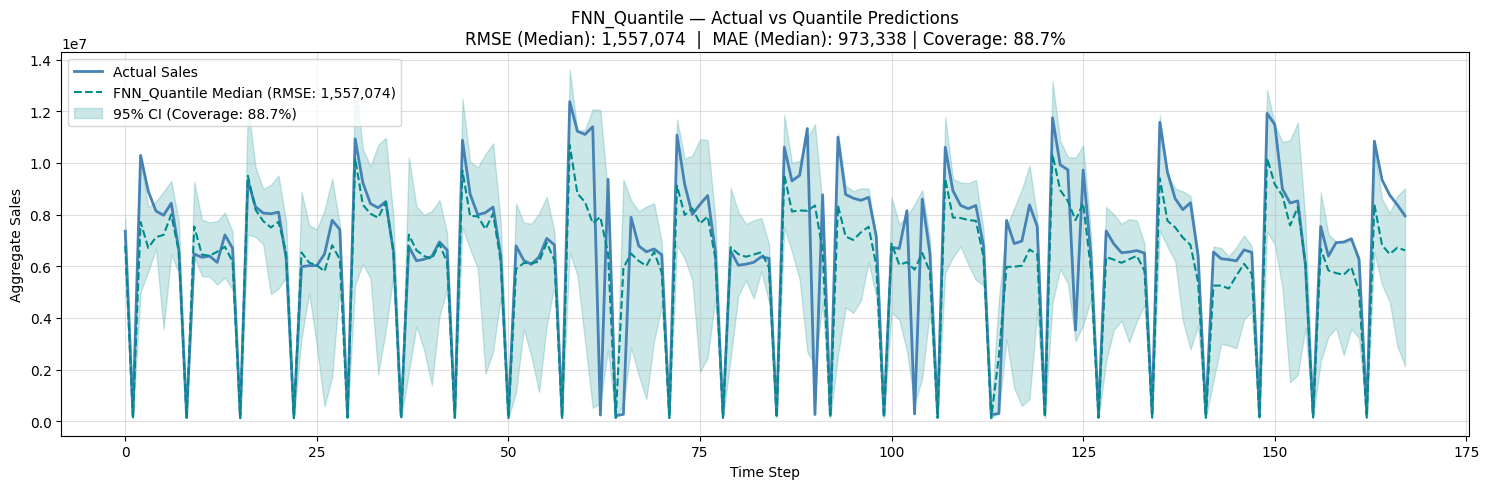

In [ ]:
plot_quantile_predictions(y_test_raw, q_low_fnn, q_med_fnn, q_high_fnn,
                          'FNN_Quantile', 'darkcyan', rmse_fnn_q, mae_fnn_q, coverage_fnn)

---
## 🔵 QUANTILE MODEL 1 — SimpleRNN (95% Prediction Interval)

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

seq_input = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='seq_input')
x = SimpleRNN(128, return_sequences=True, kernel_regularizer=l2(1e-4))(seq_input)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = SimpleRNN(64, return_sequences=False, kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)

future_input = Input(shape=(N_FUTURE_FEATS,), name='future_input')
combined = layers.Concatenate()([x, future_input])
out = Dense(3, activation='sigmoid')(combined)

model_rnn_quantile = Model(inputs=[seq_input, future_input], outputs=out,
                           name='SimpleRNN_Quantile_Model')
model_rnn_quantile.summary()


Model: "SimpleRNN_Quantile_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_6        │ (None, 60, 128)   │     19,328 │ seq_input[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ simple_rnn_6[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_103         │ (None, 60, 128)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_7        │ (None, 64)        │     12,352 │ dropout_103[0][0] │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ simple_rnn_7[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_104         │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_121 (Dense)   │ (None, 32)        │      2,080 │ dropout_104[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_19      │ (None, 35)        │          0 │ dense_121[0][0],  │
│ (Concatenate)       │                   │            │ future_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_122 (Dense)   │ (None, 3)         │        108 │ concatenate_19[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,636 (135.30 KB)

 Trainable params: 34,252 (133.80 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 240ms/step - loss: 0.1124 - median_mae: 0.2185 - val_loss: 0.0576 - val_median_mae: 0.1734 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0559 - median_mae: 0.1617 - val_loss: 0.0433 - val_median_mae: 0.1269 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0449 - median_mae: 0.1373 - val_loss: 0.0388 - val_median_mae: 0.1034 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0417 - median_mae: 0.1224 - val_loss: 0.0367 - val_median_mae: 0.0920 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0382 - median_mae: 0.1116 - val_loss: 0.0348 - val_median_mae: 0.0941 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0363 - median_mae: 0.0995 - val_loss: 0.0312 - val_median_mae: 0.0682 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.

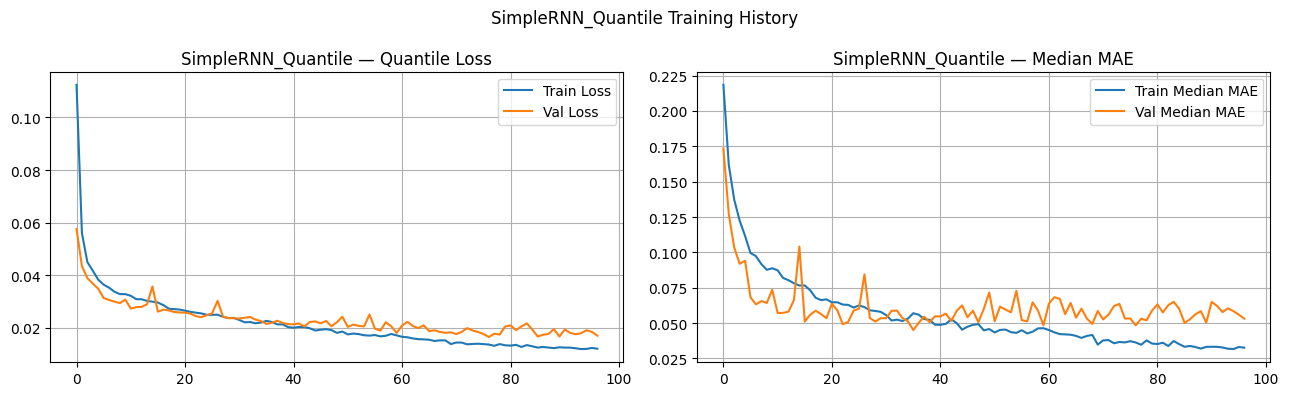

In [ ]:
model_rnn_quantile.compile(optimizer=Adam(1e-3), loss=quantile_loss, metrics=[median_mae])

history_rnn_quantile = model_rnn_quantile.fit(
    [X_seq_train, X_future_train], y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_future_test], y_test),
    callbacks=make_callbacks('RNN_Quantile'), verbose=1
)
plot_quantile_history(history_rnn_quantile, 'SimpleRNN_Quantile')


In [ ]:
y_pred_rnn_q_scaled = model_rnn_quantile.predict([X_seq_test, X_future_test])

q_low_scaled_rnn  = y_pred_rnn_q_scaled[:, 0]
q_med_scaled_rnn  = y_pred_rnn_q_scaled[:, 1]
q_high_scaled_rnn = y_pred_rnn_q_scaled[:, 2]

q_low_rnn  = target_scaler.inverse_transform(q_low_scaled_rnn.reshape(-1, 1)).flatten()
q_med_rnn  = target_scaler.inverse_transform(q_med_scaled_rnn.reshape(-1, 1)).flatten()
q_high_rnn = target_scaler.inverse_transform(q_high_scaled_rnn.reshape(-1, 1)).flatten()

print("✅ Quantile predictions made and inverse transformed for SimpleRNN.")


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step
✅ Quantile predictions made and inverse transformed for SimpleRNN.


In [ ]:
loss_025_rnn = pinball_loss_np(y_test, q_low_scaled_rnn,  0.025)
loss_05_rnn  = pinball_loss_np(y_test, q_med_scaled_rnn,  0.5)
loss_975_rnn = pinball_loss_np(y_test, q_high_scaled_rnn, 0.975)
avg_pinball_rnn = (loss_025_rnn + loss_05_rnn + loss_975_rnn) / 3

print(f"Pinball Loss (q=0.025) SimpleRNN: {loss_025_rnn:.4f}")
print(f"Pinball Loss (q=0.5)   SimpleRNN: {loss_05_rnn:.4f}")
print(f"Pinball Loss (q=0.975) SimpleRNN: {loss_975_rnn:.4f}")
print(f"Average Pinball Loss   SimpleRNN: {avg_pinball_rnn:.4f}")

coverage_rnn = np.mean((y_test_raw >= q_low_rnn) & (y_test_raw <= q_high_rnn))
print(f"95% Interval Coverage  SimpleRNN: {coverage_rnn:.2%}")

rmse_rnn_q = np.sqrt(mean_squared_error(y_test_raw, q_med_rnn))
mae_rnn_q  = mean_absolute_error(y_test_raw, q_med_rnn)
print(f"SimpleRNN Quantile (Median) RMSE: {rmse_rnn_q:>12,.2f}  |  MAE: {mae_rnn_q:>12,.2f}")

quantile_results['SimpleRNN_Quantile'] = (q_med_rnn, rmse_rnn_q, mae_rnn_q, coverage_rnn)

Pinball Loss (q=0.025) SimpleRNN: 0.0069
Pinball Loss (q=0.5)   SimpleRNN: 0.0247
Pinball Loss (q=0.975) SimpleRNN: 0.0044
Average Pinball Loss   SimpleRNN: 0.0120
95% Interval Coverage  SimpleRNN: 93.45%
SimpleRNN Quantile (Median) RMSE: 1,499,490.96  |  MAE:   765,609.82


In [ ]:
# Save SimpleRNN Quantile model
model_rnn_quantile.save(SAVE_PATH + "rnn_quantile_model.h5")
model_rnn_quantile.save(SAVE_PATH + "rnn_quantile_model.keras")
with open(SAVE_PATH + "rnn_quantile_model.pkl", "wb") as f:
    pickle.dump(model_rnn_quantile, f)

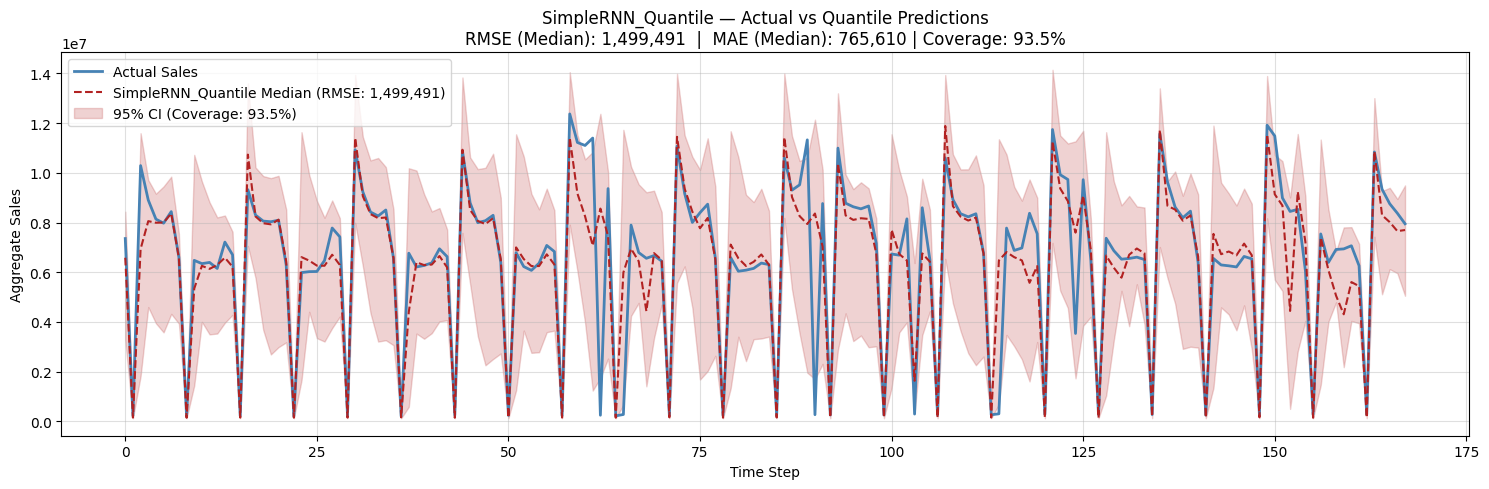

In [ ]:
plot_quantile_predictions(y_test_raw, q_low_rnn, q_med_rnn, q_high_rnn,
                          'SimpleRNN_Quantile', 'firebrick', rmse_rnn_q, mae_rnn_q, coverage_rnn)

---
## 🟠 QUANTILE MODEL 2 — GRU (95% Prediction Interval)

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

seq_input = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='seq_input')
x = GRU(128, return_sequences=True, kernel_regularizer=l2(1e-4))(seq_input)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = GRU(64, return_sequences=False, kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)

future_input = Input(shape=(N_FUTURE_FEATS,), name='future_input')
combined = layers.Concatenate()([x, future_input])
out = Dense(3, activation='sigmoid')(combined)

model_gru_quantile = Model(inputs=[seq_input, future_input], outputs=out,
                           name='GRU_Quantile_Model')
model_gru_quantile.summary()


Model: "GRU_Quantile_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_6 (GRU)         │ (None, 60, 128)   │     58,368 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ gru_6[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_105         │ (None, 60, 128)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_7 (GRU)         │ (None, 64)        │     37,248 │ dropout_105[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ gru_7[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_106         │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_123 (Dense)   │ (None, 32)        │      2,080 │ dropout_106[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_20      │ (None, 35)        │          0 │ dense_123[0][0],  │
│ (Concatenate)       │                   │            │ future_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_124 (Dense)   │ (None, 3)         │        108 │ concatenate_20[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 98,572 (385.05 KB)

 Trainable params: 98,188 (383.55 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0712 - median_mae: 0.1758 - val_loss: 0.0715 - val_median_mae: 0.1337 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0541 - median_mae: 0.1577 - val_loss: 0.0661 - val_median_mae: 0.1306 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0496 - median_mae: 0.1472 - val_loss: 0.0614 - val_median_mae: 0.1319 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0466 - median_mae: 0.1385 - val_loss: 0.0591 - val_median_mae: 0.1346 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0442 - median_mae: 0.1300 - val_loss: 0.0578 - val_median_mae: 0.1357 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0403 - median_mae: 0.1142 - val_loss: 0.0555 - val_median_mae: 0.1314 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.03

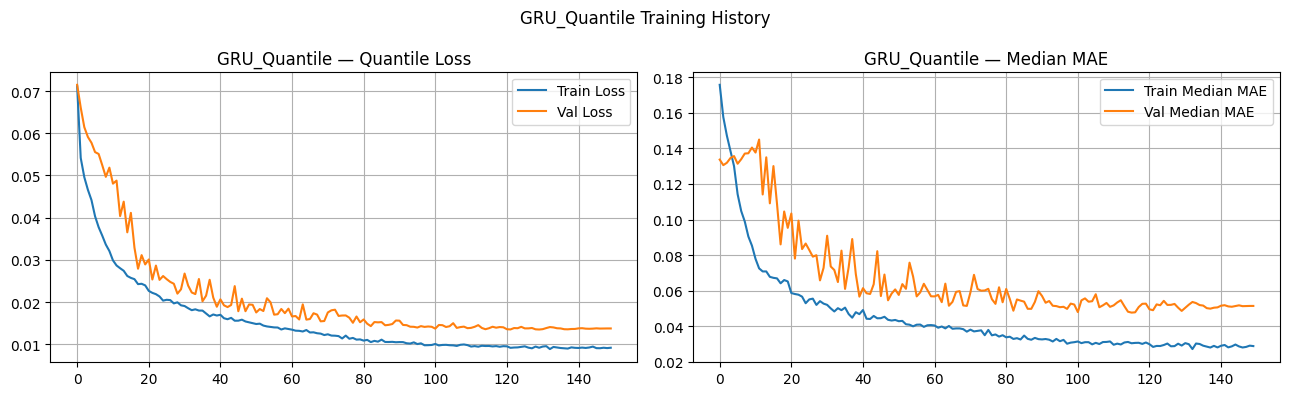

In [ ]:
model_gru_quantile.compile(optimizer=Adam(1e-3), loss=quantile_loss, metrics=[median_mae])

history_gru_quantile = model_gru_quantile.fit(
    [X_seq_train, X_future_train], y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_future_test], y_test),
    callbacks=make_callbacks('GRU_Quantile'), verbose=1
)
plot_quantile_history(history_gru_quantile, 'GRU_Quantile')


In [ ]:
y_pred_gru_q_scaled = model_gru_quantile.predict([X_seq_test, X_future_test])

q_low_scaled_gru  = y_pred_gru_q_scaled[:, 0]
q_med_scaled_gru  = y_pred_gru_q_scaled[:, 1]
q_high_scaled_gru = y_pred_gru_q_scaled[:, 2]

q_low_gru  = target_scaler.inverse_transform(q_low_scaled_gru.reshape(-1, 1)).flatten()
q_med_gru  = target_scaler.inverse_transform(q_med_scaled_gru.reshape(-1, 1)).flatten()
q_high_gru = target_scaler.inverse_transform(q_high_scaled_gru.reshape(-1, 1)).flatten()

print("✅ Quantile predictions made and inverse transformed for GRU.")


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
✅ Quantile predictions made and inverse transformed for GRU.


In [ ]:
loss_025_gru = pinball_loss_np(y_test, q_low_scaled_gru,  0.025)
loss_05_gru  = pinball_loss_np(y_test, q_med_scaled_gru,  0.5)
loss_975_gru = pinball_loss_np(y_test, q_high_scaled_gru, 0.975)
avg_pinball_gru = (loss_025_gru + loss_05_gru + loss_975_gru) / 3

print(f"Pinball Loss (q=0.025) GRU: {loss_025_gru:.4f}")
print(f"Pinball Loss (q=0.5)   GRU: {loss_05_gru:.4f}")
print(f"Pinball Loss (q=0.975) GRU: {loss_975_gru:.4f}")
print(f"Average Pinball Loss   GRU: {avg_pinball_gru:.4f}")

coverage_gru = np.mean((y_test_raw >= q_low_gru) & (y_test_raw <= q_high_gru))
print(f"95% Interval Coverage  GRU: {coverage_gru:.2%}")

rmse_gru_q = np.sqrt(mean_squared_error(y_test_raw, q_med_gru))
mae_gru_q  = mean_absolute_error(y_test_raw, q_med_gru)
print(f"GRU Quantile (Median) RMSE: {rmse_gru_q:>12,.2f}  |  MAE: {mae_gru_q:>12,.2f}")

quantile_results['GRU_Quantile'] = (q_med_gru, rmse_gru_q, mae_gru_q, coverage_gru)

Pinball Loss (q=0.025) GRU: 0.0068
Pinball Loss (q=0.5)   GRU: 0.0240
Pinball Loss (q=0.975) GRU: 0.0029
Average Pinball Loss   GRU: 0.0113
95% Interval Coverage  GRU: 95.83%
GRU Quantile (Median) RMSE: 1,677,920.00  |  MAE:   744,937.62


In [ ]:
# Save GRU Quantile model
model_gru_quantile.save(SAVE_PATH + "gru_quantile_model.h5")
model_gru_quantile.save(SAVE_PATH + "gru_quantile_model.keras")
with open(SAVE_PATH + "gru_quantile_model.pkl", "wb") as f:
    pickle.dump(model_gru_quantile, f)

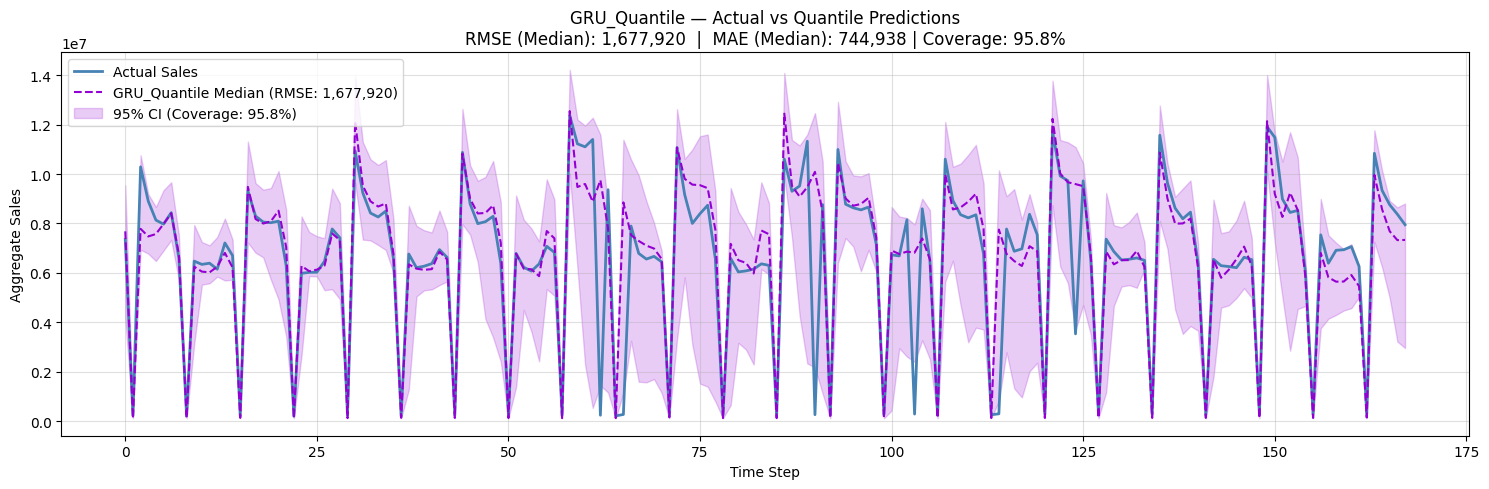

In [ ]:
plot_quantile_predictions(y_test_raw, q_low_gru, q_med_gru, q_high_gru,
                          'GRU_Quantile', 'darkviolet', rmse_gru_q, mae_gru_q, coverage_gru)

---
## 🟤 QUANTILE MODEL 3 — N-HiTS (95% Prediction Interval)

> Re-uses the `NHiTSBlock` class defined in Part 1 (MODEL 7).

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

INPUT_SIZE = X_seq_train.shape[1]
FEAT_DIM   = X_seq_train.shape[2]
POOL_SIZES = [2, 4, 8]

seq_input = Input(shape=(INPUT_SIZE, FEAT_DIM), name='seq_input')
residual  = Flatten()(seq_input)
forecasts = []

for ps in POOL_SIZES:
    reshaped   = layers.Reshape((INPUT_SIZE, FEAT_DIM))(
                    layers.Dense(INPUT_SIZE * FEAT_DIM)(residual)
                 )
    block      = NHiTSBlock(INPUT_SIZE * FEAT_DIM, 64, pool_size=ps, units=256)
    bc, fc     = block(reshaped)
    residual   = layers.Subtract()([residual, bc])
    forecasts.append(fc)

nhits_add = layers.Add()(forecasts)
x         = Dense(64, activation='relu')(nhits_add)
x         = Dropout(0.2)(x)

future_input = Input(shape=(N_FUTURE_FEATS,), name='future_input')
combined = layers.Concatenate()([x, future_input])
out = Dense(3, activation='sigmoid')(combined)

model_nhits_quantile = Model(inputs=[seq_input, future_input], outputs=out,
                             name='NHiTS_Quantile_Model')
model_nhits_quantile.summary()


Model: "NHiTS_Quantile_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_66          │ (None, 1320)      │          0 │ seq_input[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_125 (Dense)   │ (None, 1320)      │  1,743,720 │ flatten_66[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_9 (Reshape) │ (None, 60, 22)    │          0 │ dense_125[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n_hi_ts_block_9     │ [(None, 1320),    │    761,704 │ reshape_9[0][0]   │
│ (NHiTSBlock)        │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_9          │ (None, 1320)      │          0 │ flatten_66[0][0], │
│ (Subtract)          │                   │            │ n_hi_ts_block_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_130 (Dense)   │ (None, 1320)      │  1,743,720 │ subtract_9[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_10          │ (None, 60, 22)    │          0 │ dense_130[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n_hi_ts_block_10    │ [(None, 1320),    │    761,704 │ reshape_10[0][0]  │
│ (NHiTSBlock)        │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_10         │ (None, 1320)      │          0 │ subtract_9[0][0], │
│ (Subtract)          │                   │            │ n_hi_ts_block_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_135 (Dense)   │ (None, 1320)      │  1,743,720 │ subtract_10[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_11          │ (None, 60, 22)    │          0 │ dense_135[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n_hi_ts_block_11    │ [(None, 1320),    │    761,704 │ reshape_11[0][0]  │
│ (NHiTSBlock)        │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 64)        │          0 │ n_hi_ts_block_9[… │
│                     │                   │            │ n_hi_ts_block_10… │
│                     │                   │            │ n_hi_ts_block_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_140 (Dense)   │ (None, 64)        │      4,160 │ add_11[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_113         │ (None, 64)        │          0 │ dense_140[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_21      │ (None, 67)        │          0 │ dropout_113[0][0… │
│ (Concatenate)       │                   │            │ future_input[0][

 Total params: 7,520,636 (28.69 MB)

 Trainable params: 7,517,564 (28.68 MB)

 Non-trainable params: 3,072 (12.00 KB)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 410ms/step - loss: 0.0707 - median_mae: 0.2598 - val_loss: 0.0777 - val_median_mae: 0.4228 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0508 - median_mae: 0.2491 - val_loss: 0.0777 - val_median_mae: 0.4228 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0475 - median_mae: 0.2361 - val_loss: 0.0777 - val_median_mae: 0.4225 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0453 - median_mae: 0.2212 - val_loss: 0.0699 - val_median_mae: 0.3751 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0419 - median_mae: 0.2023 - val_loss: 0.0697 - val_median_mae: 0.3721 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0402 - median_mae: 0.1911 - val_loss: 0.0574 - val_median_mae: 0.3019 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.

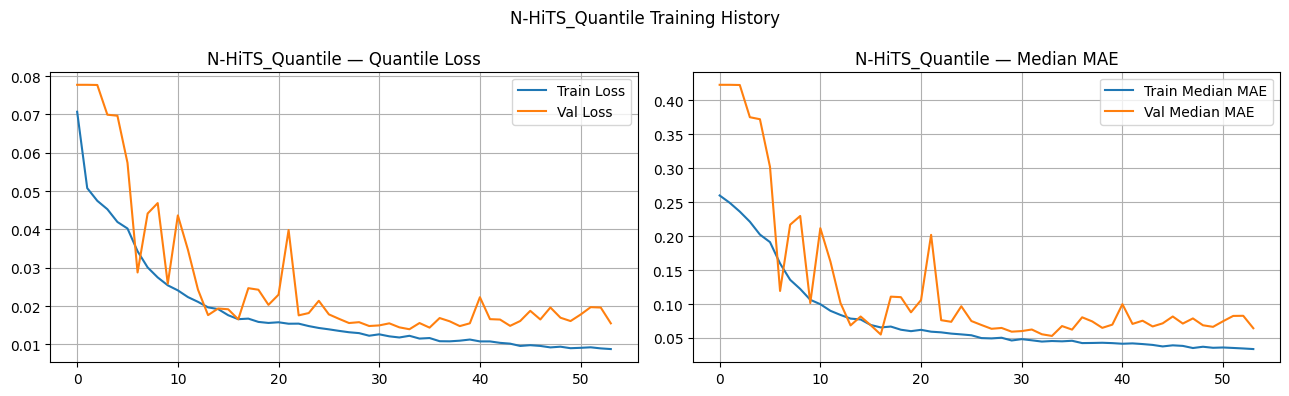

In [ ]:
model_nhits_quantile.compile(optimizer=Adam(1e-3), loss=quantile_loss, metrics=[median_mae])

history_nhits_quantile = model_nhits_quantile.fit(
    [X_seq_train, X_future_train], y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_future_test], y_test),
    callbacks=make_callbacks('NHiTS_Quantile'), verbose=1
)
plot_quantile_history(history_nhits_quantile, 'N-HiTS_Quantile')


In [ ]:
y_pred_nhits_q_scaled = model_nhits_quantile.predict([X_seq_test, X_future_test])

q_low_scaled_nhits  = y_pred_nhits_q_scaled[:, 0]
q_med_scaled_nhits  = y_pred_nhits_q_scaled[:, 1]
q_high_scaled_nhits = y_pred_nhits_q_scaled[:, 2]

q_low_nhits  = target_scaler.inverse_transform(q_low_scaled_nhits.reshape(-1, 1)).flatten()
q_med_nhits  = target_scaler.inverse_transform(q_med_scaled_nhits.reshape(-1, 1)).flatten()
q_high_nhits = target_scaler.inverse_transform(q_high_scaled_nhits.reshape(-1, 1)).flatten()

print("✅ Quantile predictions made and inverse transformed for N-HiTS.")


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step
✅ Quantile predictions made and inverse transformed for N-HiTS.


In [ ]:
loss_025_nhits = pinball_loss_np(y_test, q_low_scaled_nhits,  0.025)
loss_05_nhits  = pinball_loss_np(y_test, q_med_scaled_nhits,  0.5)
loss_975_nhits = pinball_loss_np(y_test, q_high_scaled_nhits, 0.975)
avg_pinball_nhits = (loss_025_nhits + loss_05_nhits + loss_975_nhits) / 3

print(f"Pinball Loss (q=0.025) N-HiTS: {loss_025_nhits:.4f}")
print(f"Pinball Loss (q=0.5)   N-HiTS: {loss_05_nhits:.4f}")
print(f"Pinball Loss (q=0.975) N-HiTS: {loss_975_nhits:.4f}")
print(f"Average Pinball Loss   N-HiTS: {avg_pinball_nhits:.4f}")

coverage_nhits = np.mean((y_test_raw >= q_low_nhits) & (y_test_raw <= q_high_nhits))
print(f"95% Interval Coverage  N-HiTS: {coverage_nhits:.2%}")

rmse_nhits_q = np.sqrt(mean_squared_error(y_test_raw, q_med_nhits))
mae_nhits_q  = mean_absolute_error(y_test_raw, q_med_nhits)
print(f"N-HiTS Quantile (Median) RMSE: {rmse_nhits_q:>12,.2f}  |  MAE: {mae_nhits_q:>12,.2f}")

quantile_results['N-HiTS_Quantile'] = (q_med_nhits, rmse_nhits_q, mae_nhits_q, coverage_nhits)

Pinball Loss (q=0.025) N-HiTS: 0.0076
Pinball Loss (q=0.5)   N-HiTS: 0.0266
Pinball Loss (q=0.975) N-HiTS: 0.0077
Average Pinball Loss   N-HiTS: 0.0139
95% Interval Coverage  N-HiTS: 82.74%
N-HiTS Quantile (Median) RMSE: 1,594,812.59  |  MAE:   823,939.08


In [ ]:
# Save N-HiTS Quantile model
model_nhits_quantile.save(SAVE_PATH + "nhits_quantile_model.h5")
model_nhits_quantile.save(SAVE_PATH + "nhits_quantile_model.keras")
with open(SAVE_PATH + "nhits_quantile_model.pkl", "wb") as f:
    pickle.dump(model_nhits_quantile, f)

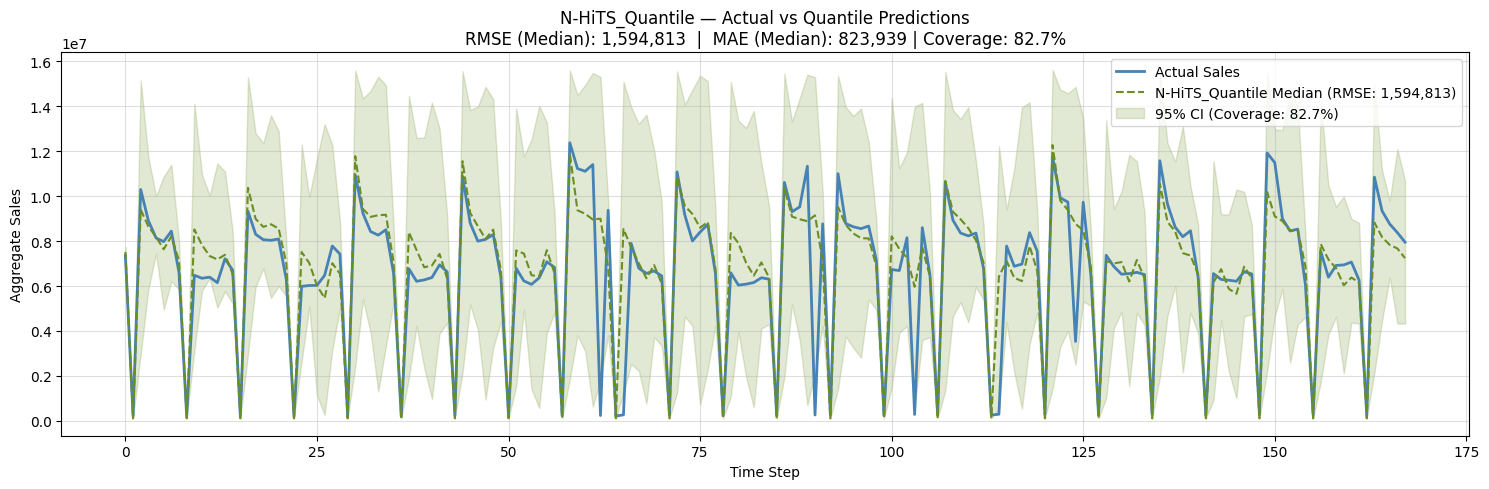

In [ ]:
plot_quantile_predictions(y_test_raw, q_low_nhits, q_med_nhits, q_high_nhits,
                          'N-HiTS_Quantile', 'olivedrab', rmse_nhits_q, mae_nhits_q, coverage_nhits)

---
## 📊 PART 2 FINAL — Quantile Model Comparison

In [ ]:
q_comparison = pd.DataFrame([
    {'Model': name, 'Median RMSE': rmse, 'Median MAE': mae, 'Coverage': coverage}
    for name, (_, rmse, mae, coverage) in quantile_results.items()
]).sort_values('Median RMSE').reset_index(drop=True)

print('\n📊 Quantile Model Comparison — Median Prediction (lower is better):')
display(q_comparison.style
    .format({'Median RMSE': '{:,.2f}', 'Median MAE': '{:,.2f}', 'Coverage': '{:.2%}'})
    .background_gradient(subset=['Median RMSE', 'Median MAE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Coverage'], cmap='RdYlGn'))


📊 Quantile Model Comparison — Median Prediction (lower is better):


,Model,Median RMSE,Median MAE,Coverage
0,SimpleRNN_Quantile,"1,499,490.96","765,609.82",93.45%
1,FNN_Quantile,"1,557,074.15","973,338.08",88.69%
2,N-HiTS_Quantile,"1,594,812.59","823,939.08",82.74%
3,GRU_Quantile,"1,677,920.00","744,937.62",95.83%


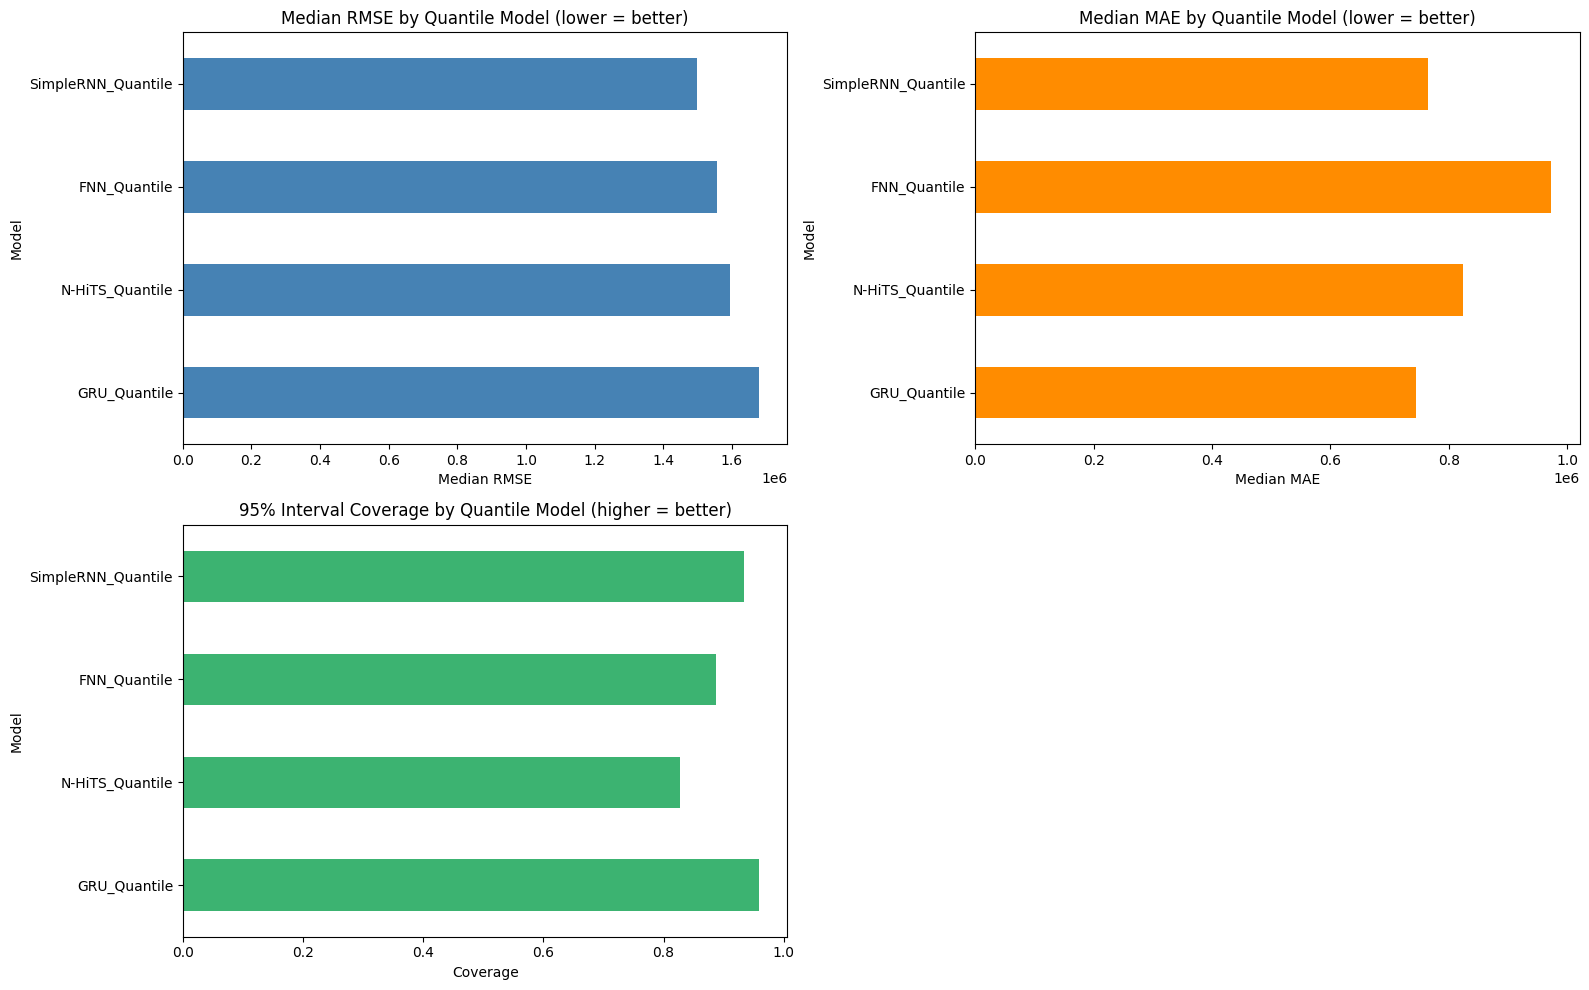


🏆 Best quantile model: SimpleRNN_Quantile  →  RMSE: 1,499,490.96  |  MAE: 765,609.82 | Coverage: 93.45%


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10)) # Adjust figsize and layout for 4 plots
axes = axes.flatten() # Flatten for easier iteration

# RMSE Plot
q_comparison.plot.barh(x='Model', y='Median RMSE', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Median RMSE by Quantile Model (lower = better)'); axes[0].set_xlabel('Median RMSE')
axes[0].invert_yaxis()

# MAE Plot
q_comparison.plot.barh(x='Model', y='Median MAE', ax=axes[1], color='darkorange', legend=False)
axes[1].set_title('Median MAE by Quantile Model (lower = better)');  axes[1].set_xlabel('Median MAE')
axes[1].invert_yaxis()

# Coverage Plot
q_comparison.plot.barh(x='Model', y='Coverage', ax=axes[2], color='mediumseagreen', legend=False) # New color for Coverage
axes[2].set_title('95% Interval Coverage by Quantile Model (higher = better)'); axes[2].set_xlabel('Coverage')
axes[2].invert_yaxis() # Invert for consistency in ordering, but note 'higher = better' in title

fig.delaxes(axes[3]) # Remove the 4th (empty) subplot

plt.tight_layout(); plt.show()

best_q = q_comparison.iloc[0]
print(f"\n🏆 Best quantile model: {best_q['Model']}  →  "
      f"RMSE: {best_q['Median RMSE']:,.2f}  |  MAE: {best_q['Median MAE']:,.2f} | Coverage: {best_q['Coverage']:.2%}")